In [2]:
# Only for execution in Google Colab

from google.colab import drive
drive.mount('/content/drive', force_remount=True)  # Add My Drive/<>
import os
os.chdir("/content/drive/Shareddrives/ISBA2403 Group 9")

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, roc_auc_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

## Part 0 · Objective & Setup

Binary classification: predict whether a driver will accept a coupon (Y=1) or decline (Y=0).

Pipeline: **EDA → Preprocessing → Clustering → Model Training → Evaluation**

In [4]:
# Define Objective and Target
TARGET = "Y"  # coupon accepted (1) / not accepted (0)
RANDOM_STATE = 42

### 0.1 Data Loading

In [5]:
df_vehicle_coupon = pd.read_csv('../data/in-vehicle-coupon-dataset.csv')
df_vehicle_coupon.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


### 0.2 Missing Data Handling

#### Percentage of missing data in each column

In [6]:
df_vehicle_coupon.coupon.values

array(['Restaurant(<20)', 'Coffee House', 'Carry out & Take away', ...,
       'Coffee House', 'Bar', 'Restaurant(20-50)'], dtype=object)

In [7]:
df_vehicle_coupon.isna().sum()/df_vehicle_coupon.shape[0]*100

,0
destination,0.000000
passanger,0.000000
weather,0.000000
temperature,0.000000
time,0.000000
coupon,0.000000
expiration,0.000000
gender,0.000000
age,0.000000
maritalStatus,0.000000


#### Drop column "car" with over 99% missing value

In [8]:
df_cleaned = df_vehicle_coupon.drop(columns=['car'])

#### Fill missing behavioral columns with 'never' before mapping (missing = never visited)

In [9]:
nan_cols = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']
for col in nan_cols:
    df_cleaned[col] = df_cleaned[col].fillna('never')

### 0.3 Rename features to remove ambituity with coupon labels

In [10]:
df = df_cleaned.rename(columns={
    'Bar': 'Bar_Freq',
    'CoffeeHouse': 'Coffee_Freq',
    'CarryAway': 'Takeout_Freq',
    'RestaurantLessThan20': 'Restaurant20_Freq',
    'Restaurant20To50': 'Restaurant20to50_Freq'})

---
## Part 1 · Exploratory Data Analysis

Explore the raw data before any transformation: shape, missing values, target balance, and key feature patterns.

### 1.1 Overview

In [11]:
df.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
print(f'Shape: {df.shape}')
print(f'\nTarget distribution:')
print(df['Y'].value_counts())
print(f'Acceptance rate: {df["Y"].mean():.3f}')
print(f'\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head(3)

Shape: (12684, 25)

Target distribution:
Y
1    7210
0    5474
Name: count, dtype: int64
Acceptance rate: 0.568

Missing values:
Series([], dtype: int64)


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,Coffee_Freq,Takeout_Freq,Restaurant20_Freq,Restaurant20to50_Freq,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,0,0,1,1


### 1.2 Target distribution & acceptance rate by coupon type

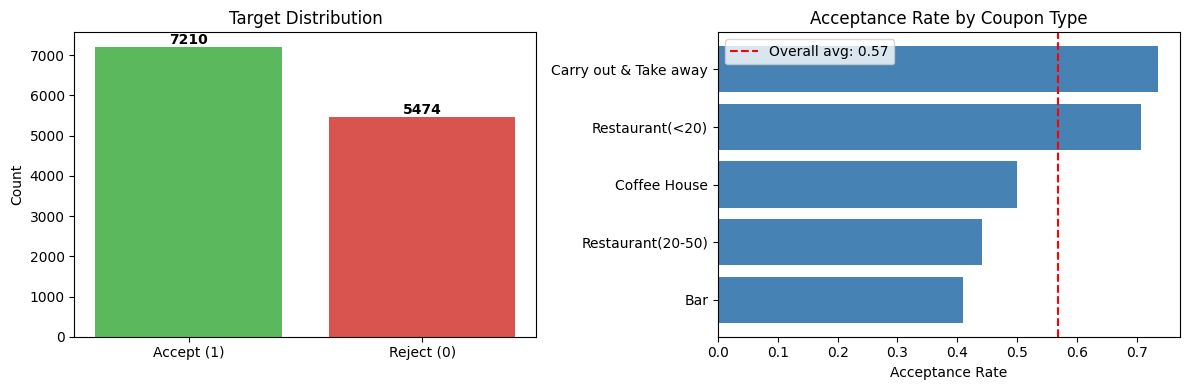

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Y'].value_counts()
axes[0].bar(['Accept (1)', 'Reject (0)'], counts.values, color=['#5cb85c', '#d9534f'])
axes[0].set_title('Target Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 60, str(v), ha='center', fontweight='bold')

coupon_acc = df.groupby('coupon')['Y'].mean().sort_values()
axes[1].barh(coupon_acc.index, coupon_acc.values, color='steelblue')
axes[1].axvline(df['Y'].mean(), color='red', linestyle='--', label=f'Overall avg: {df["Y"].mean():.2f}')
axes[1].set_title('Acceptance Rate by Coupon Type')
axes[1].set_xlabel('Acceptance Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

### 1.3 Behavioral features vs acceptance rate

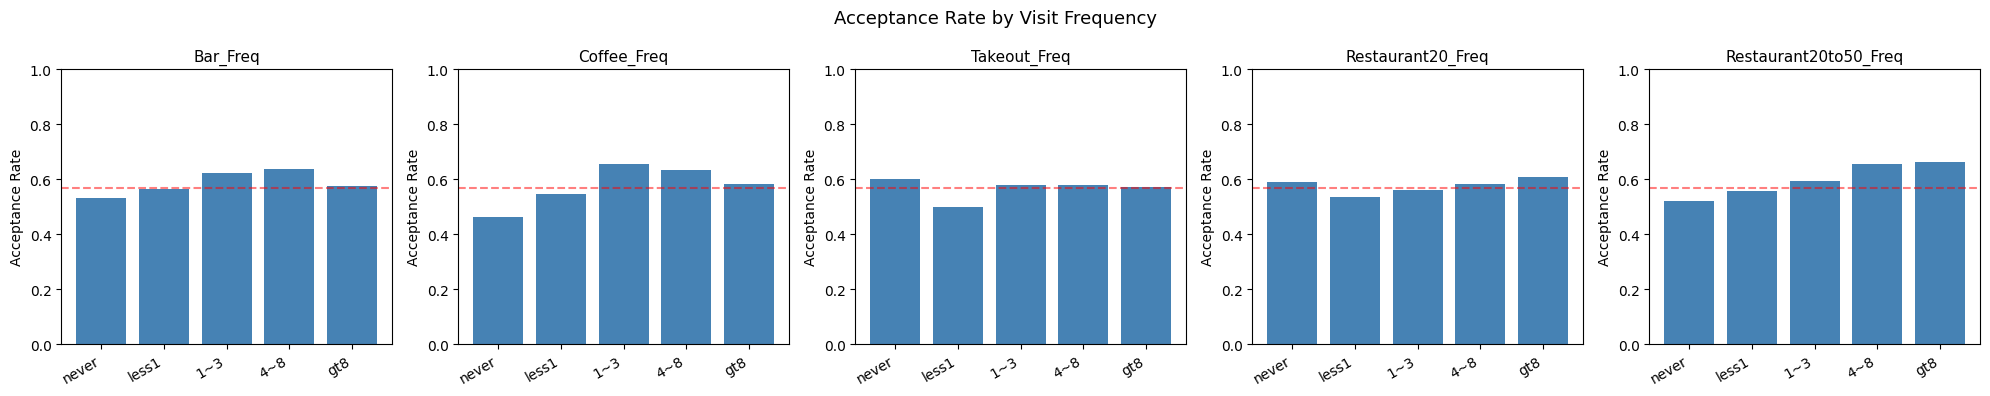

In [14]:
freq_cols_raw = ['Bar_Freq', 'Coffee_Freq', 'Takeout_Freq', 'Restaurant20_Freq', 'Restaurant20to50_Freq']
freq_order = ['never', 'less1', '1~3', '4~8', 'gt8']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, freq_cols_raw):
    order = [x for x in freq_order if x in df[col].dropna().unique()]
    rates = df.groupby(col)['Y'].mean().reindex(order)
    ax.bar(range(len(rates)), rates.values, color='steelblue')
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(order, rotation=30, ha='right')
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Acceptance Rate')
    ax.set_ylim(0, 1)
    ax.axhline(df['Y'].mean(), color='red', linestyle='--', alpha=0.5)

plt.suptitle('Acceptance Rate by Visit Frequency', fontsize=13)
plt.tight_layout()
plt.show()

### 1.4 Customer Segmentation: Identifying High-Value Demographics

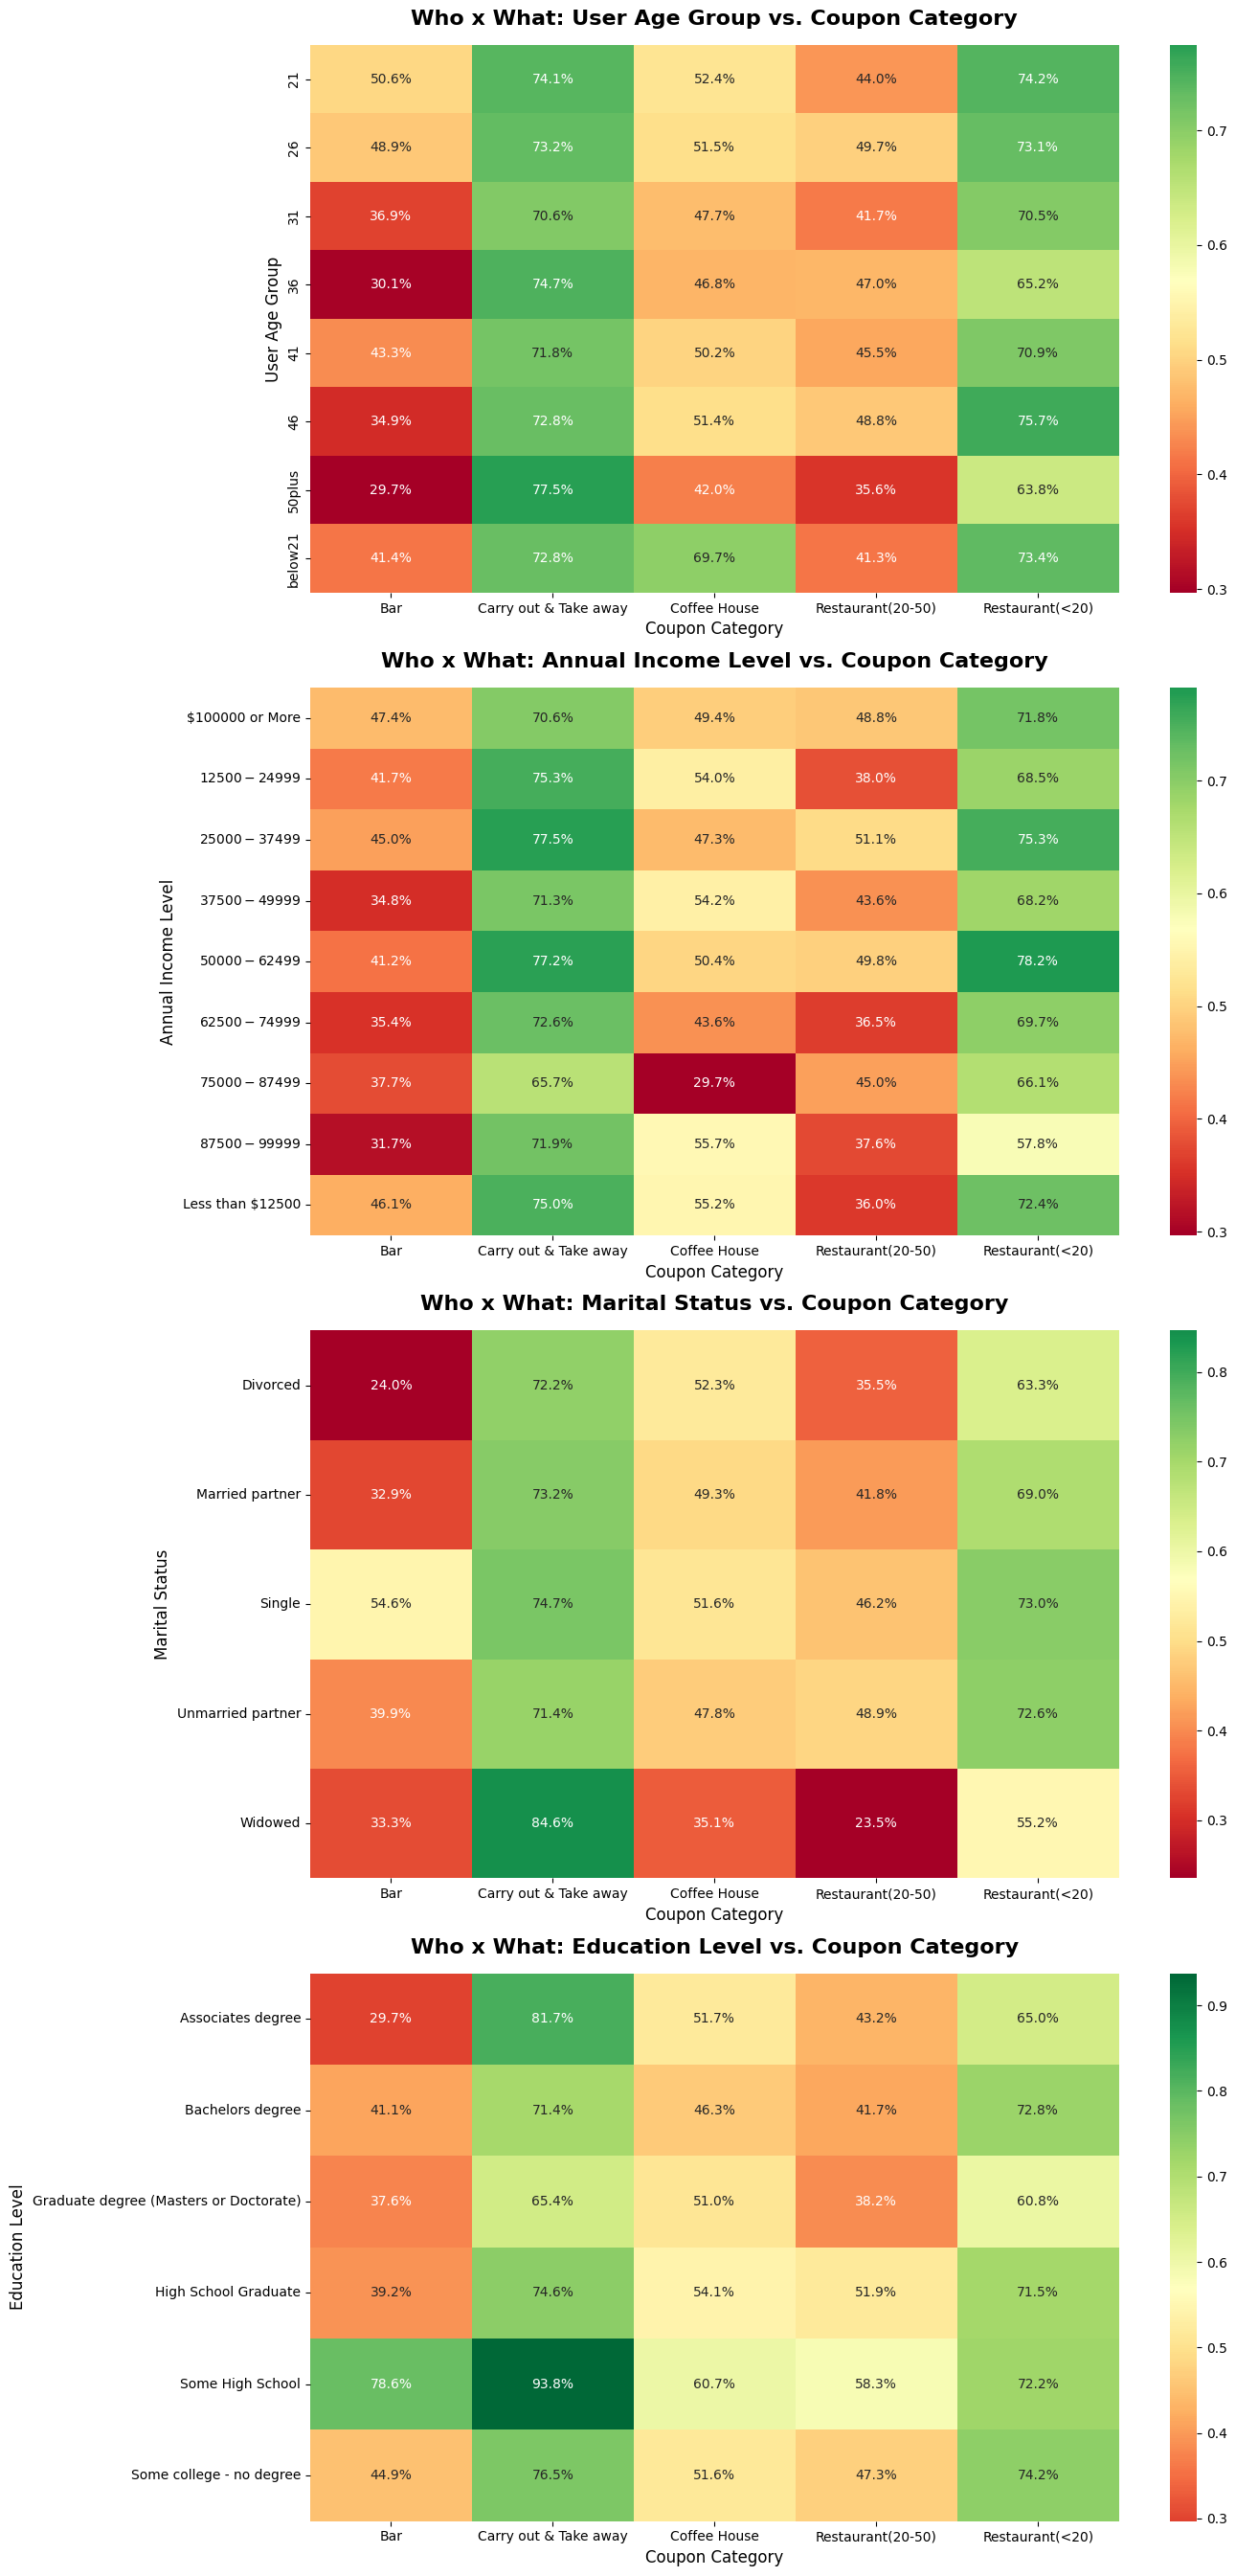

In [15]:
# --- Expanded "Who x What" Analysis (Dynamic Citing) ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cite the demographics directly from your DataFrame columns
demographics = [
    ('age', 'User Age Group'),
    ('income', 'Annual Income Level'),
    ('maritalStatus', 'Marital Status'),
    ('education', 'Education Level')
]

fig, axes = plt.subplots(len(demographics), 1, figsize=(14, 22 + 5 * (len(demographics) - 3))) # Adjust figsize dynamically
overall_avg = df['Y'].mean()

for i, (col, title) in enumerate(demographics):
    if col not in df.columns:
        print(f"Warning: {col} not found in dataframe.")
        continue

    # Create the pivot table
    pivot = df.pivot_table(index=col, columns='coupon', values='Y', aggfunc='mean')

    # Cite and Sort: Instead of redefining, we sort the index values found in the data
    # Note: For 'age' and 'income' strings, a simple sort() might need help
    # but citing them directly ensures we don't miss any categories.
    pivot = pivot.sort_index()

    # Plotting the Heatmap
    sns.heatmap(pivot, annot=True, fmt=".1%", cmap='RdYlGn', center=overall_avg, ax=axes[i])

    axes[i].set_title(f'Who x What: {title} vs. Coupon Category', fontsize=16, fontweight='bold', pad=15)
    axes[i].set_ylabel(title, fontsize=12)
    axes[i].set_xlabel('Coupon Category', fontsize=12)

plt.tight_layout()
plt.show()

### 1.5 Environmental Features Analysis: Time & Weather Context

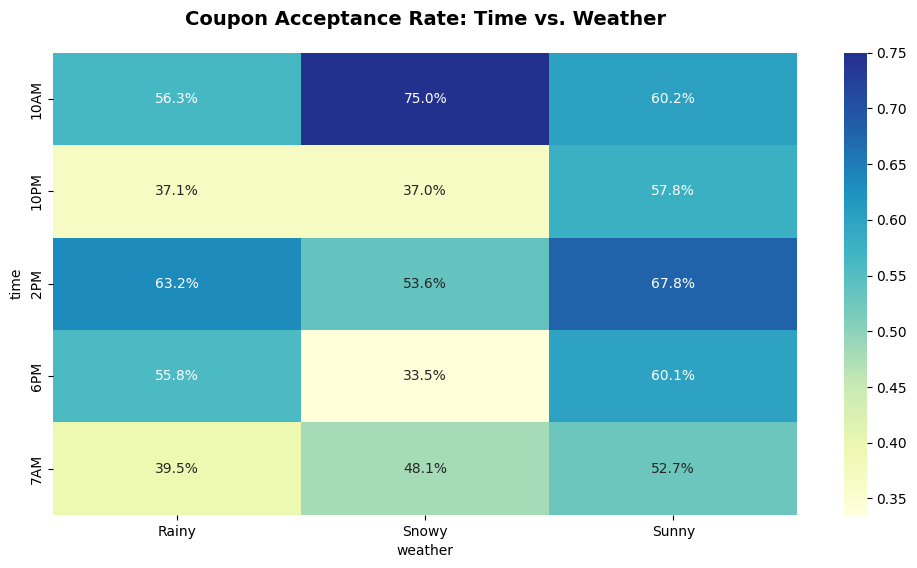

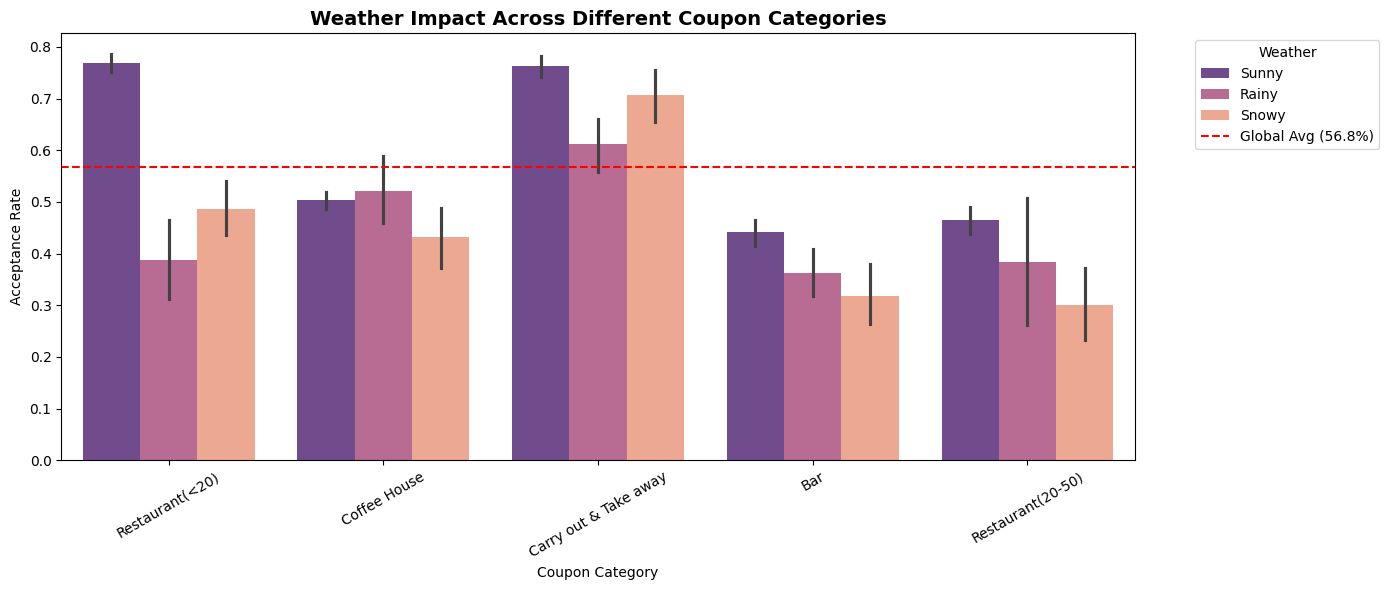

In [16]:
# 1. Interaction Heatmap: Time/Weather
plt.figure(figsize=(12, 6))

# Identify which time column exists (time or time_num)
t_col = 'time' if 'time' in df.columns else 'time_num'

try:
    pivot_time_weather = df.pivot_table(index=t_col, columns='weather', values='Y', aggfunc='mean')

    # Cite the index directly and sort it
    # If using 'time' (strings like 7AM), we sort to ensure logical flow
    pivot_time_weather = pivot_time_weather.sort_index()

    sns.heatmap(pivot_time_weather, annot=True, fmt=".1%", cmap='YlGnBu', center=df['Y'].mean())
    plt.title(f'Coupon Acceptance Rate: {t_col.capitalize()} vs. Weather', fontsize=14, fontweight='bold', pad=20)
    plt.show()
except KeyError as e:
    print(f"Error: {e}. Please ensure 'weather' and a time column exist in your df.")

# 2. Acceptance by Weather & Coupon Type
plt.figure(figsize=(14, 6))

# Citing 'coupon', 'Y', and 'weather' directly from the dataset
sns.barplot(data=df, x='coupon', y='Y', hue='weather', palette='magma', alpha=0.8)
plt.axhline(df['Y'].mean(), color='red', linestyle='--', label=f'Global Avg ({df["Y"].mean():.1%})')

plt.title('Weather Impact Across Different Coupon Categories', fontsize=14, fontweight='bold')
plt.ylabel('Acceptance Rate')
plt.xlabel('Coupon Category')
plt.xticks(rotation=30)
plt.legend(title='Weather', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6643/453372333.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=acceptance_by_time.index, y=acceptance_by_time.values, palette='viridis')


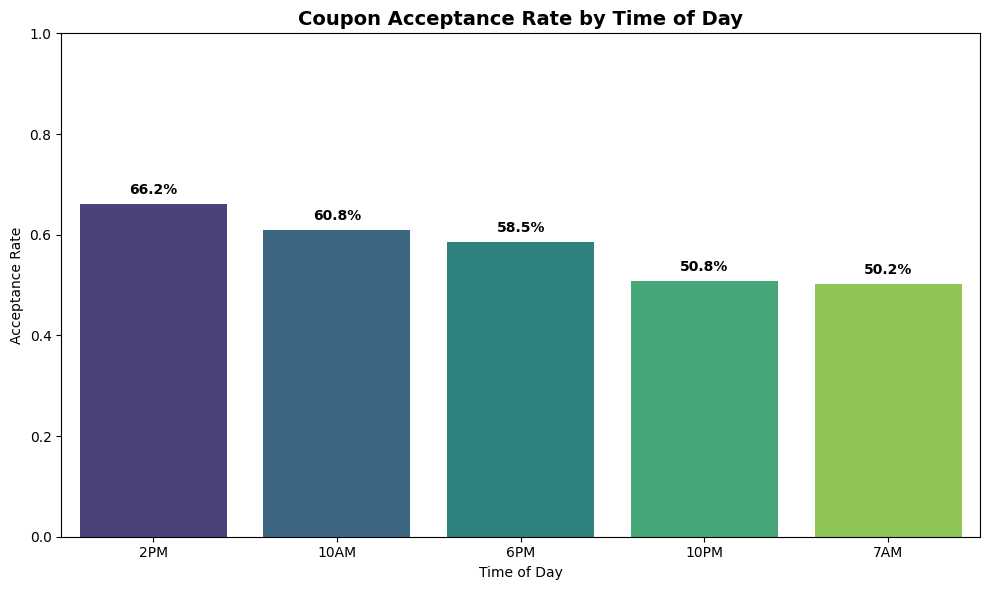

In [17]:
# Group by 'time' and calculate the mean of 'Y' (acceptance rate)
acceptance_by_time = df.groupby('time')['Y'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=acceptance_by_time.index, y=acceptance_by_time.values, palette='viridis')

# Formatting
plt.title('Coupon Acceptance Rate by Time of Day', fontsize=14, fontweight='bold')
plt.ylabel('Acceptance Rate')
plt.xlabel('Time of Day')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for percentage

# Adding labels
for i, val in enumerate(acceptance_by_time.values):
    plt.text(i, val + 0.02, f'{val:.1%}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_6643/4258049426.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=expiration_analysis.index, y=expiration_analysis.values, palette='magma')


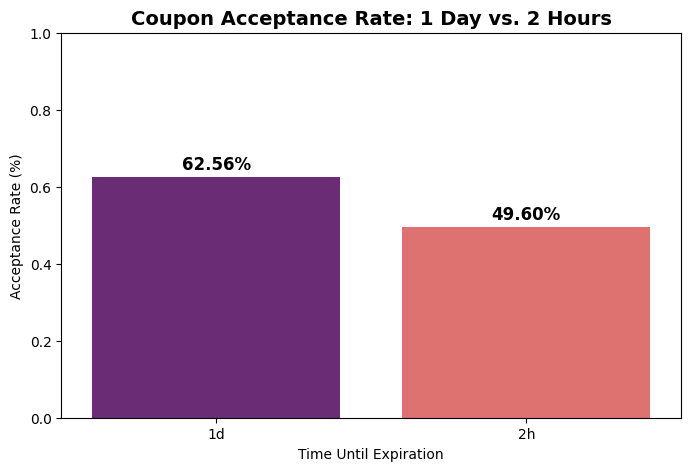

In [18]:
# Grouping by Expiration and calculating mean of Y (Acceptance Rate)
expiration_analysis = df.groupby('expiration')['Y'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=expiration_analysis.index, y=expiration_analysis.values, palette='magma')

# Formatting
plt.title('Coupon Acceptance Rate: 1 Day vs. 2 Hours', fontsize=14, fontweight='bold')
plt.ylabel('Acceptance Rate (%)')
plt.xlabel('Time Until Expiration')
plt.ylim(0, 1)

# Adding labels
for i, val in enumerate(expiration_analysis.values):
    plt.text(i, val + 0.02, f'{val:.2%}', ha='center', fontsize=12, fontweight='bold')

plt.show()

---
## Part 2 · Preprocessing

### 2.1 Ordinal Encoding

Ordinal string columns are mapped to numeric values that preserve natural ordering:

| Column | Mapping |
|---|---|
| `age` | below21=18, 21=21, 26=26, 31=31, 36=36, 41=41, 46=46, 50plus=55 |
| `income` | interval midpoints (e.g. $12.5k–$25k → 18,750; $100k+ → 110,000) |
| `time` | 7AM=7, 10AM=10, 2PM=14, 6PM=18, 10PM=22 |
| Behavioral freq cols | never=0, less1=0.5, 1~3=2, 4~8=6, gt8=9 |

Original string columns are dropped after `_num` versions are created to avoid double-counting in the ColumnTransformer.

In [19]:
age_map   = {"below21":18, "21":21, "26":26, "31":31, "36":36, "41":41, "46":46, "50plus":55}
income_map = {
    "Less than $12500":6250, "$12500 - $24999":18750, "$25000 - $37499":31250,
    "$37500 - $49999":43750, "$50000 - $62499":56250, "$62500 - $74999":68750,
    "$75000 - $87499":81250, "$87500 - $99999":93750, "$100000 or More":110000
}
time_map  = {"7AM":7, "10AM":10, "2PM":14, "6PM":18, "10PM":22}
visit_map = {"never":0, "less1":0.5, "1~3":2, "4~8":6, "gt8":9}

for col, mp in [
    ("age", age_map), ("income", income_map), ("time", time_map),
    ("Bar_Freq", visit_map), ("Coffee_Freq", visit_map), ("Takeout_Freq", visit_map),
    ("Restaurant20_Freq", visit_map), ("Restaurant20to50_Freq", visit_map)
]:
    if col in df.columns:
        df[f"{col}_num"] = df[col].map(mp)

# Drop original string columns after _num versions created
original_mapped_cols = ['age', 'income', 'time', 'Bar_Freq', 'Coffee_Freq',
                        'Takeout_Freq', 'Restaurant20_Freq', 'Restaurant20to50_Freq']
df = df.drop(columns=[c for c in original_mapped_cols if c in df.columns])
print(f"Columns after encoding: {df.shape[1]}")

Columns after encoding: 25


### 2.2 Feature Engineering

- **`toCoupon_GEQ5min`**: dropped — near-constant (99% = 1), no predictive value
- **`direction_consistency`**: created as `direction_same - direction_opp`;
original two columns dropped because `direction_same + direction_opp = 1` always holds (perfect collinearity)

In [20]:
if 'toCoupon_GEQ5min' in df.columns:
    df = df.drop(columns=['toCoupon_GEQ5min'])

if {"direction_same", "direction_opp"}.issubset(df.columns):
    df["direction_consistency"] = df["direction_same"] - df["direction_opp"]
    df = df.drop(columns=["direction_same", "direction_opp"])

print(f"Final feature count: {df.shape[1] - 1} features + 1 target")

Final feature count: 22 features + 1 target


### 2.3 ColumnTransformer Setup

A shared `preprocessor` is defined here and fit in Section 3.3 (train set only):

- **Numeric**: median imputation → `StandardScaler`
- **Categorical**: mode imputation → `OneHotEncoder`

In [21]:
X = df.drop(columns=["Y"]) if "Y" in df.columns else df.copy()
num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
cat_cols = [c for c in X.columns if c not in num_cols]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc",  StandardScaler(with_mean=False))
    ]), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("oh",  OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
])

print(f"Numeric features : {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")

Numeric features : 13
Categorical features: 9


---
## Part 3 · Clustering & Feature Augmentation

### 3.1 Selecting Optimal K

Use **Elbow Method** (inertia) and **Silhouette Score** to determine the best number of clusters.

**Clustering features: demographic + behavioral only** (8 columns)
- `age_num`, `income_num`, `has_children`, `Bar_num`, `CoffeeHouse_num`, `CarryAway_num`, `RestaurantLessThan20_num`, `Restaurant20To50_num`
- Contextual and coupon features excluded — clustering should capture stable *user type*, not user-situation combinations

> Note: scaler and KMeans fit on full data here for K exploration only. Section 3.2 fits on train set only.

In [22]:
CLUSTER_COLS = ['age_num', 'income_num', 'has_children',
                'Bar_Freq_num', 'Coffee_Freq_num', 'Takeout_Freq_num',
                'Restaurant20_Freq_num', 'Restaurant20to50_Freq_num']
cluster_cols = [c for c in CLUSTER_COLS if c in X.columns]

scaler_explore = StandardScaler()
X_cluster_explore = scaler_explore.fit_transform(X[cluster_cols].dropna())
print(f"\nRows used for K selection: {X_cluster_explore.shape[0]}")


Rows used for K selection: 12684


In [23]:
k_values = list(range(2, 11))
inertias = []
sil_scores = []

for k in k_values:
    km_tmp = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km_tmp.fit_predict(X_cluster_explore)
    inertias.append(km_tmp.inertia_)
    sil_scores.append(
        silhouette_score(X_cluster_explore, labels,
                         sample_size=min(4000, X_cluster_explore.shape[0]),
                         random_state=42)
    )

print("k	inertia	silhouette")
for k, iner, sil in zip(k_values, inertias, sil_scores):
    print(f"{k}	{iner:.2f}	{sil:.4f}")

k	inertia	silhouette
2	84612.82	0.2027
3	72556.91	0.1876
4	65846.26	0.1953
5	59474.43	0.2004
6	54824.16	0.2030
7	51668.78	0.1985
8	49102.60	0.1948
9	46429.88	0.1908
10	44120.08	0.2028


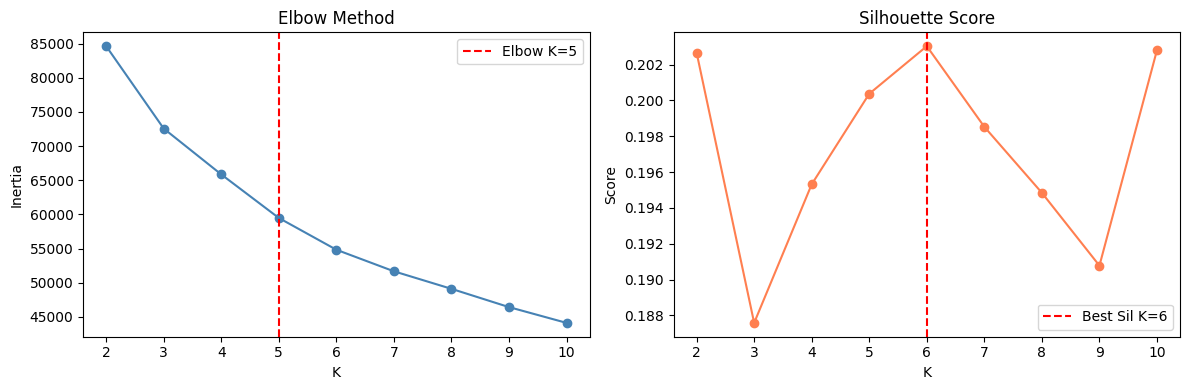

Elbow suggests K=5,  Silhouette suggests K=6


In [24]:
# Compute elbow K (point of maximum curvature)
x = np.array(k_values, dtype=float)
y_in = np.array(inertias, dtype=float)
line = np.array([x[-1] - x[0], y_in[-1] - y_in[0]], dtype=float)
norm = np.linalg.norm(line)
dist_to_line = []
for xi, yi in zip(x, y_in):
    p = np.array([xi - x[0], yi - y_in[0]], dtype=float)
    dist_to_line.append(abs(line[0] * p[1] - line[1] * p[0]) / norm)

elbow_k = int(x[np.argmax(dist_to_line)])
sil_k   = int(k_values[np.argmax(sil_scores)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, inertias, marker="o", color="steelblue")
axes[0].axvline(elbow_k, color="red", linestyle="--", label=f"Elbow K={elbow_k}")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].legend()

axes[1].plot(k_values, sil_scores, marker="o", color="coral")
axes[1].axvline(sil_k, color="red", linestyle="--", label=f"Best Sil K={sil_k}")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Elbow suggests K={elbow_k},  Silhouette suggests K={sil_k}")

### K Selection Decision: K = 5

Based on the elbow and silhouette plots above, **K = 5** is selected.

- Elbow method suggests K = 5
- Silhouette score at K = 5 is meaningfully higher than K = 4

The 5 clusters represent distinct user personas used as additional features in the classification models.

### 3.2 Leakage-Safe Cluster Features + Baseline Validation

- `preprocessor` and `cluster_scaler` fit on **train set only**, applied to test set
- KMeans uses the same 8 demographic + behavioral features
- Cluster features appended to full preprocessed feature set

**Two datasets for downstream modeling (Part 4):**

| Variable | Features | Purpose |
|---|---|---|
| `X_train_base` / `X_test_base` | Original features only | Baseline |
| `X_train_cluster` / `X_test_cluster` | Original + cluster features | Enhanced |

The Logistic Regression run below is a **quick validation** that the pipeline executes correctly — full model training is in Part 4.

In [25]:
# leakage-safe cluster features + classification (k=5, 70/30)
X = df.drop(columns=["Y"])
y = df["Y"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, stratify=y, random_state=42
)

# Full preprocessing — fit on train only
num_cols = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]
cat_cols = [c for c in X_train.columns if c not in num_cols]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler(with_mean=False))
    ]), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("oh", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
])

X_train_base = preprocessor.fit_transform(X_train)
X_test_base  = preprocessor.transform(X_test)

# KMeans on demographic + behavioral features only (user persona clustering)
# Demographic + behavioral features only — defines stable user persona
# Excludes contextual (weather, destination...) and coupon features
CLUSTER_COLS = ['age_num', 'income_num', 'has_children',
                'Bar_Freq_num', 'Coffee_Freq_num', 'Takeout_Freq_num',
                'Restaurant20_Freq_num', 'Restaurant20to50_Freq_num']
cluster_cols = [c for c in CLUSTER_COLS if c in X_train.columns]

cluster_scaler = StandardScaler()
X_train_cluster = cluster_scaler.fit_transform(X_train[cluster_cols])
X_test_cluster  = cluster_scaler.transform(X_test[cluster_cols])

k = 5
km = KMeans(n_clusters=k, n_init=20, random_state=42)
train_cluster_labels = km.fit_predict(X_train_cluster)
test_cluster_labels  = km.predict(X_test_cluster)

# Cluster features: one-hot membership + distance to each centroid
train_ohe  = np.eye(k)[train_cluster_labels]
test_ohe   = np.eye(k)[test_cluster_labels]
train_dist = km.transform(X_train_cluster)
test_dist  = km.transform(X_test_cluster)

# Append cluster features to full preprocessed feature set
X_train_cluster = sparse.hstack([
    X_train_base,
    sparse.csr_matrix(train_ohe),
    sparse.csr_matrix(train_dist)
]).tocsr()

X_test_cluster = sparse.hstack([
    X_test_base,
    sparse.csr_matrix(test_ohe),
    sparse.csr_matrix(test_dist)
]).tocsr()

clf = LogisticRegression(max_iter=2000, random_state=42)
clf.fit(X_train_cluster, y_train)

pred  = clf.predict(X_test_cluster)
proba = clf.predict_proba(X_test_cluster)[:, 1]

print("Test AUC:", round(roc_auc_score(y_test, proba), 4))
print("Test F1 :", round(f1_score(y_test, pred), 4))
print(classification_report(y_test, pred, digits=4))


Test AUC: 0.7243
Test F1 : 0.7314
              precision    recall  f1-score   support

           0     0.6487    0.5484    0.5943      1643
           1     0.6930    0.7744    0.7314      2163

    accuracy                         0.6768      3806
   macro avg     0.6708    0.6614    0.6629      3806
weighted avg     0.6739    0.6768    0.6723      3806



### 3.3 Cluster Profiles & Visualization

Visualize the 5 clusters and interpret each one based on demographic + behavioral features.

In [26]:
from sklearn.decomposition import PCA
import seaborn as sns

cluster_cols = [c for c in CLUSTER_COLS if c in X_train.columns]

# ── 1. Cluster profile table ──────────────────────────────────────────────────
train_profile = X_train[cluster_cols].copy()
train_profile['cluster'] = train_cluster_labels
train_profile['Y'] = y_train.values

profile = train_profile.groupby('cluster').agg(
    count=('Y', 'count'),
    acceptance_rate=('Y', 'mean'),
    **{col: (col, 'mean') for col in cluster_cols}
).round(2)

print("=== Cluster Profile Table ===")
print(profile.to_string())

=== Cluster Profile Table ===
         count  acceptance_rate  age_num  income_num  has_children  Bar_Freq_num  Coffee_Freq_num  Takeout_Freq_num  Restaurant20_Freq_num  Restaurant20to50_Freq_num
cluster                                                                                                                                                              
0         2746             0.57    25.56    45915.88          0.00          0.60             1.52              2.80                   2.29                       0.72
1          658             0.66    30.95    59076.75          0.37          2.95             4.63              5.62                   6.77                       6.85
2         1801             0.58    33.85    63198.22          0.43          0.72             3.55              6.73                   6.32                       0.98
3         2891             0.51    41.71    54011.59          0.89          0.44             1.48              2.71                   2.14  

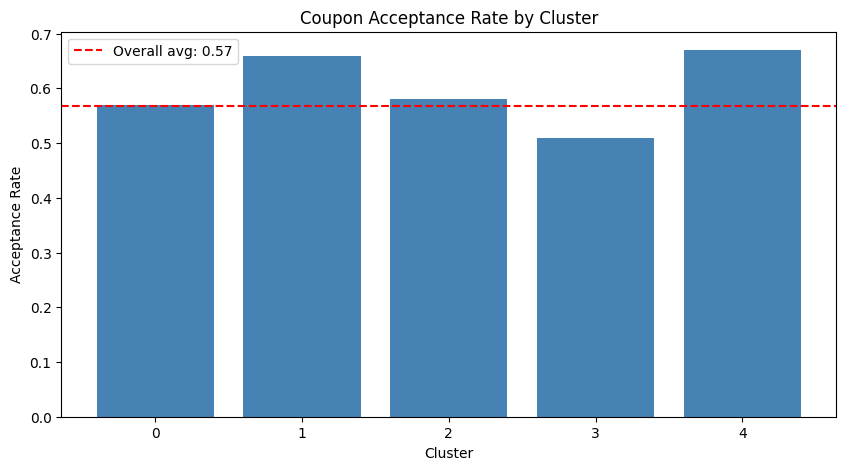

In [27]:
# ── 2. Acceptance rate by cluster ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

acc = profile['acceptance_rate']
ax.bar(acc.index, acc.values, color='steelblue')
ax.axhline(y_train.mean(), color='red', linestyle='--',
                label=f'Overall avg: {y_train.mean():.2f}')
ax.set_xlabel('Cluster')
ax.set_ylabel('Acceptance Rate')
ax.set_title('Coupon Acceptance Rate by Cluster')
ax.set_xticks(range(k))
ax.legend()

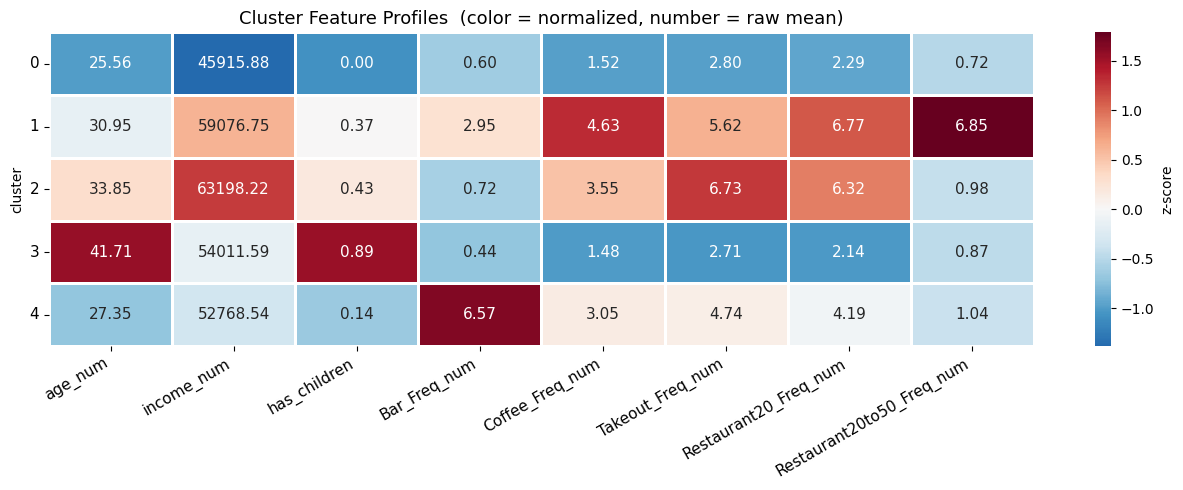

In [28]:
# ── 3. Feature heatmap ───────────────────────────────────────────────────────
profile_feats = profile[cluster_cols]
profile_norm  = (profile_feats - profile_feats.mean()) / (profile_feats.std() + 1e-8)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(profile_norm, annot=profile_feats.values, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=1,
            annot_kws={'size': 11}, cbar_kws={'label': 'z-score'},
            ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_title('Cluster Feature Profiles  (color = normalized, number = raw mean)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 4 · Model Training

Each model is trained **twice** using the datasets produced in Part 3:

| Run | Input | Purpose |
|---|---|---|
| Baseline | `X_train_base` / `X_test_base` | No cluster features |
| Enhanced | `X_train_cluster` / `X_test_cluster` | With cluster features |

Models: Logistic Regression · Random Forest · XGBoost

### 4.1 Logistic Regression

#### Model Training

In [29]:
# ── Logistic Regression ─────────────────────────────────────────────────

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score

# 1. Baseline Model (No cluster features)
# Uses X_train_base and X_test_base
print("--- [RUN 1: BASELINE LOGISTIC REGRESSION] ---")
lr_base = LogisticRegression(max_iter=2000, random_state=42)
lr_base.fit(X_train_base, y_train)

# Predictions
y_pred_base = lr_base.predict(X_test_base)
y_prob_base = lr_base.predict_proba(X_test_base)[:, 1]

# Evaluation
base_auc = roc_auc_score(y_test, y_prob_base)
base_f1 = f1_score(y_test, y_pred_base)

print(f"Baseline AUC: {base_auc:.4f}")
print(f"Baseline F1 : {base_f1:.4f}")
print("\nBaseline Classification Report:")
print(classification_report(y_test, y_pred_base, digits=4))


# 2. Enhanced Model (With cluster features)
# Uses X_train_cluster and X_test_cluster
print("\n--- [RUN 2: ENHANCED LOGISTIC REGRESSION] ---")
lr_enhanced = LogisticRegression(max_iter=2000, random_state=42)
lr_enhanced.fit(X_train_cluster, y_train)

# Predictions
y_pred_enh = lr_enhanced.predict(X_test_cluster)
y_prob_enh = lr_enhanced.predict_proba(X_test_cluster)[:, 1]

# Evaluation
enh_auc = roc_auc_score(y_test, y_prob_enh)
enh_f1 = f1_score(y_test, y_pred_enh)

print(f"Enhanced AUC: {enh_auc:.4f}")
print(f"Enhanced F1 : {enh_f1:.4f}")
print("\nEnhanced Classification Report:")
print(classification_report(y_test, y_pred_enh, digits=4))

# --- Comparison Summary ---
print("\n--- [COMPARISON SUMMARY] ---")
print(f"AUC Improvement: {enh_auc - base_auc:.4f}")
print(f"F1 Improvement : {enh_f1 - base_f1:.4f}")

--- [RUN 1: BASELINE LOGISTIC REGRESSION] ---
Baseline AUC: 0.7228
Baseline F1 : 0.7302

Baseline Classification Report:
              precision    recall  f1-score   support

           0     0.6464    0.5575    0.5987      1643
           1     0.6957    0.7684    0.7302      2163

    accuracy                         0.6774      3806
   macro avg     0.6711    0.6629    0.6645      3806
weighted avg     0.6744    0.6774    0.6734      3806


--- [RUN 2: ENHANCED LOGISTIC REGRESSION] ---
Enhanced AUC: 0.7243
Enhanced F1 : 0.7314

Enhanced Classification Report:
              precision    recall  f1-score   support

           0     0.6487    0.5484    0.5943      1643
           1     0.6930    0.7744    0.7314      2163

    accuracy                         0.6768      3806
   macro avg     0.6708    0.6614    0.6629      3806
weighted avg     0.6739    0.6768    0.6723      3806


--- [COMPARISON SUMMARY] ---
AUC Improvement: 0.0015
F1 Improvement : 0.0012


#### Deep DIve of Logistic Regression

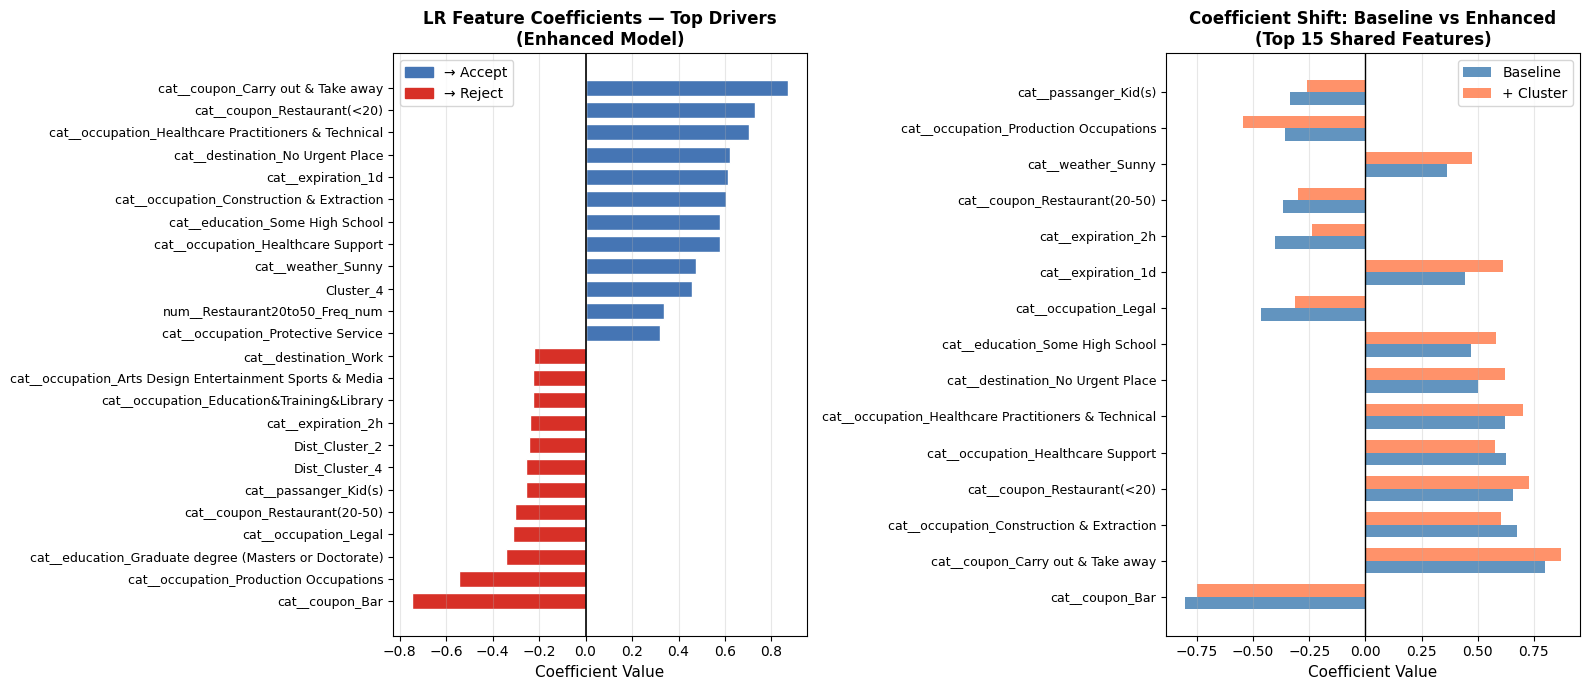

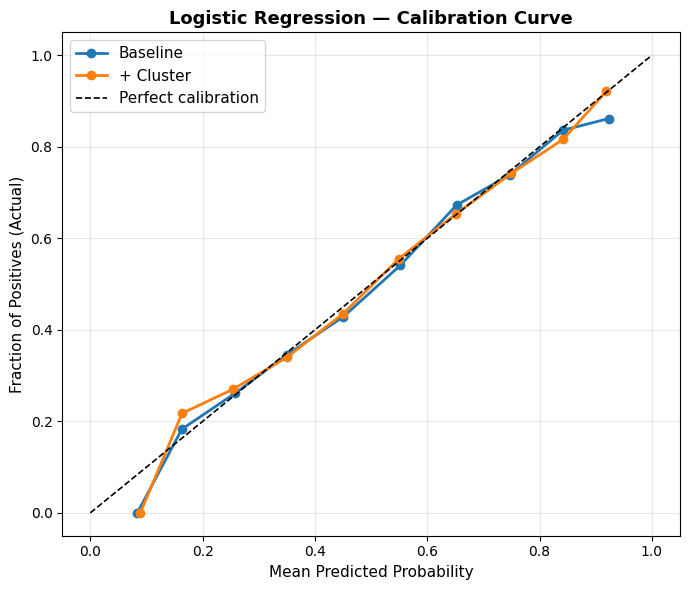

In [30]:
# ── LR Feature Importance Deep-Dive ─────────────────────────────────────────
import matplotlib.patches as mpatches
from sklearn.calibration import calibration_curve as cal_curve

base_feat_names_lr = list(preprocessor.get_feature_names_out())
cluster_feat_names_lr = ([f'Cluster_{i}' for i in range(5)] +
                         [f'Dist_Cluster_{i}' for i in range(5)])
all_lr_feat_names = base_feat_names_lr + cluster_feat_names_lr

# ── 1. Signed coefficient bar — top positive & negative drivers ───────────────
coefs = lr_enhanced.coef_[0]
coef_df = pd.DataFrame({'Feature': all_lr_feat_names, 'Coefficient': coefs})
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
top_pos = coef_df[coef_df['Coefficient'] > 0].nlargest(12, 'AbsCoef')
top_neg = coef_df[coef_df['Coefficient'] < 0].nsmallest(12, 'Coefficient')
top_signed = pd.concat([top_neg, top_pos]).sort_values('Coefficient')

bar_colors = ['#d73027' if c < 0 else '#4575b4' for c in top_signed['Coefficient']]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(range(len(top_signed)), top_signed['Coefficient'],
             color=bar_colors, edgecolor='white', height=0.72)
axes[0].set_yticks(range(len(top_signed)))
axes[0].set_yticklabels(top_signed['Feature'], fontsize=9)
axes[0].axvline(0, color='black', lw=1.2)
axes[0].set_xlabel('Coefficient Value', fontsize=11)
axes[0].set_title('LR Feature Coefficients — Top Drivers\n(Enhanced Model)', fontsize=12, fontweight='bold')
axes[0].legend(handles=[
    mpatches.Patch(color='#4575b4', label='→ Accept'),
    mpatches.Patch(color='#d73027', label='→ Reject')
], fontsize=10)
axes[0].grid(axis='x', alpha=0.3)

# ── 2. Baseline vs Enhanced coefficient comparison (shared features) ──────────
base_coef_df = pd.DataFrame({'Feature': base_feat_names_lr,
                              'Baseline': lr_base.coef_[0]})
enh_coef_df  = pd.DataFrame({'Feature': base_feat_names_lr,
                              'Enhanced': lr_enhanced.coef_[0][:len(base_feat_names_lr)]})
compare = base_coef_df.merge(enh_coef_df, on='Feature')
compare['Abs'] = compare['Baseline'].abs()
compare = compare.nlargest(15, 'Abs')

x = np.arange(len(compare)); w = 0.35
axes[1].barh(x - w/2, compare['Baseline'], w, label='Baseline',  color='steelblue', alpha=0.85)
axes[1].barh(x + w/2, compare['Enhanced'], w, label='+ Cluster', color='coral',     alpha=0.85)
axes[1].set_yticks(x)
axes[1].set_yticklabels(compare['Feature'], fontsize=9)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('Coefficient Value', fontsize=11)
axes[1].set_title('Coefficient Shift: Baseline vs Enhanced\n(Top 15 Shared Features)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ── 3. Calibration curve ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
for lbl, proba in [('Baseline', y_prob_base), ('+ Cluster', y_prob_enh)]:
    fp, mp = cal_curve(y_test, proba, n_bins=10, strategy='uniform')
    ax.plot(mp, fp, marker='o', lw=2, label=lbl)
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Fraction of Positives (Actual)', fontsize=11)
ax.set_title('Logistic Regression — Calibration Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 4.2 Random Forest

#### Model Training

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.metrics import roc_curve, confusion_matrix

# Baseline
rf_base_model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_base_model.fit(X_train_base, y_train)

y_proba_base_rf = rf_base_model.predict_proba(X_test_base)[:, 1]
y_pred_base_rf = rf_base_model.predict(X_test_base)

auc_base_rf = roc_auc_score(y_test, y_proba_base_rf)
f1_base_rf = f1_score(y_test, y_pred_base_rf)

print(f'Random Forest Baseline Test AUC: {auc_base_rf:.4f} F1: {f1_base_rf:.4f}')
print(classification_report(y_test, y_pred_base_rf, target_names=['Reject', 'Accept'], digits=4))

# Enhanced
rf_cluster_model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_cluster_model.fit(X_train_cluster, y_train)

y_proba_cluster_rf = rf_cluster_model.predict_proba(X_test_cluster)[:, 1]
y_pred_cluster_rf = rf_cluster_model.predict(X_test_cluster)

auc_cluster_rf = roc_auc_score(y_test, y_proba_cluster_rf)
f1_cluster_rf = f1_score(y_test, y_pred_cluster_rf)

print(f'Random Forest + Cluster Test AUC: {auc_cluster_rf:.4f} F1: {f1_cluster_rf:.4f}')
print(f'Delta AUC: {auc_cluster_rf - auc_base_rf:+.4f}')

Random Forest Baseline Test AUC: 0.8061 F1: 0.7864
              precision    recall  f1-score   support

      Reject     0.7339    0.6464    0.6874      1643
      Accept     0.7537    0.8220    0.7864      2163

    accuracy                         0.7462      3806
   macro avg     0.7438    0.7342    0.7369      3806
weighted avg     0.7452    0.7462    0.7436      3806

Random Forest + Cluster Test AUC: 0.8156 F1: 0.7939
Delta AUC: +0.0095


#### ROC Curve & Confusion Matrix

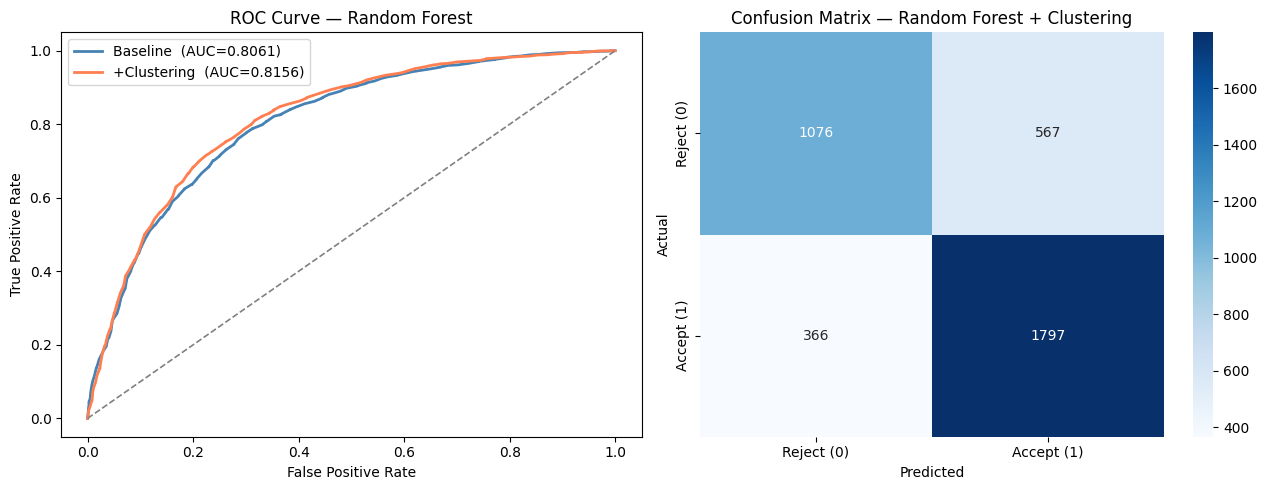

In [32]:
# ROC curves: baseline vs enhanced
fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_base_rf)
fpr_c, tpr_c, _ = roc_curve(y_test, y_proba_cluster_rf)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr_b, tpr_b, color='steelblue', lw=2, label=f'Baseline  (AUC={auc_base_rf:.4f})')
axes[0].plot(fpr_c, tpr_c, color='coral',     lw=2, label=f'+Clustering  (AUC={auc_cluster_rf:.4f})')
axes[0].plot([0,1],[0,1], color='gray', linestyle='--', lw=1.2)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Random Forest')
axes[0].legend()

# Confusion matrix for best model (cluster)
cm = confusion_matrix(y_test, y_pred_cluster_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Reject (0)', 'Accept (1)'],
            yticklabels=['Reject (0)', 'Accept (1)'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix — Random Forest + Clustering')

plt.tight_layout()
plt.show()

#### Deep Dive of Random Forest

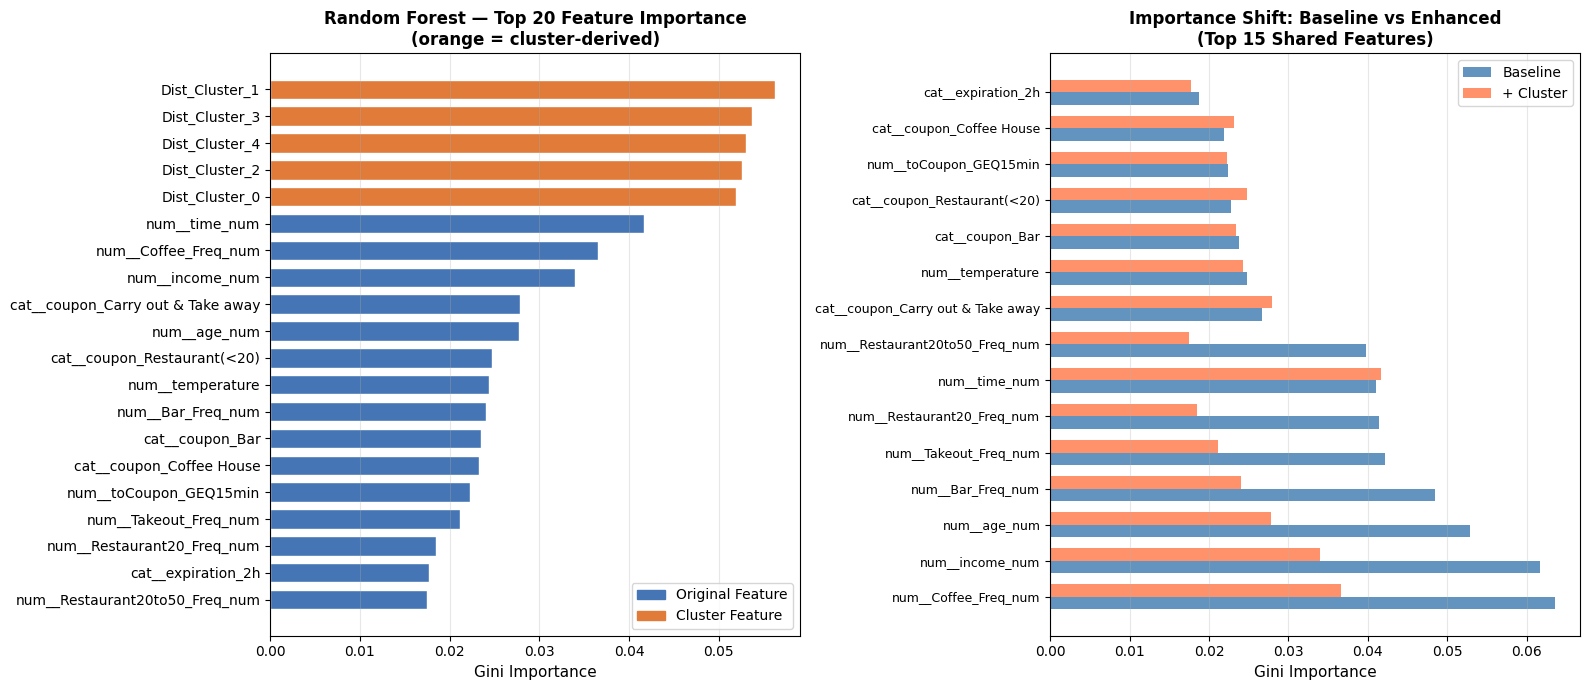

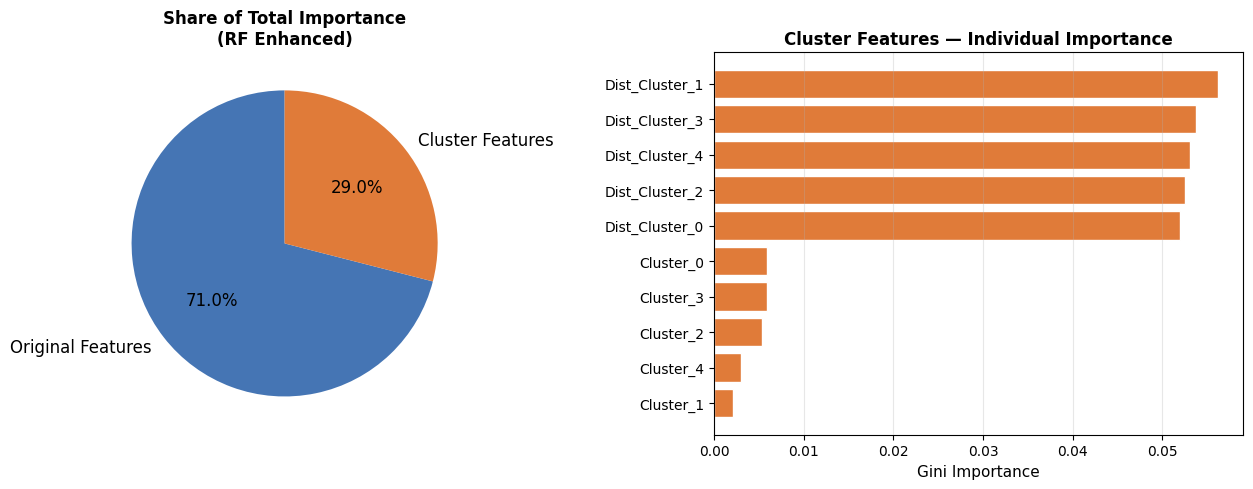

In [33]:
# ── RF Feature Importance Deep-Dive ─────────────────────────────────────────
import matplotlib.patches as mpatches

base_feat_names_rf = list(preprocessor.get_feature_names_out())
rf_cluster_ohe   = [f'Cluster_{i}' for i in range(5)]
rf_cluster_dist  = [f'Dist_Cluster_{i}' for i in range(5)]
all_rf_names     = base_feat_names_rf + rf_cluster_ohe + rf_cluster_dist

imp_all = rf_cluster_model.feature_importances_
imp_df_full = pd.DataFrame({'Feature': all_rf_names, 'Importance': imp_all})
imp_df_full['Type'] = imp_df_full['Feature'].apply(
    lambda f: 'Cluster Feature' if f.startswith('Cluster_') or f.startswith('Dist_')
              else 'Original Feature')
imp_top20 = imp_df_full.nlargest(20, 'Importance')

# ── 1. Top-20 coloured bar ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
bar_colors = ['#e07b39' if t == 'Cluster Feature' else '#4575b4'
               for t in imp_top20['Type']]
axes[0].barh(imp_top20['Feature'][::-1], imp_top20['Importance'][::-1],
             color=bar_colors[::-1], edgecolor='white', height=0.72)
axes[0].set_xlabel('Gini Importance', fontsize=11)
axes[0].set_title('Random Forest — Top 20 Feature Importance\n(orange = cluster-derived)', fontsize=12, fontweight='bold')
axes[0].legend(handles=[
    mpatches.Patch(color='#4575b4', label='Original Feature'),
    mpatches.Patch(color='#e07b39', label='Cluster Feature')
], fontsize=10)
axes[0].grid(axis='x', alpha=0.3)

# ── 2. Baseline vs Enhanced importance shift ──────────────────────────────────
imp_base_df = pd.DataFrame({'Feature': base_feat_names_rf,
                             'Baseline': rf_base_model.feature_importances_})
imp_enh_df  = pd.DataFrame({'Feature': base_feat_names_rf,
                             'Enhanced': rf_cluster_model.feature_importances_[:len(base_feat_names_rf)]})
imp_cmp = imp_base_df.merge(imp_enh_df, on='Feature').nlargest(15, 'Baseline')

x = np.arange(len(imp_cmp)); w = 0.35
axes[1].barh(x - w/2, imp_cmp['Baseline'], w, label='Baseline',  color='steelblue', alpha=0.85)
axes[1].barh(x + w/2, imp_cmp['Enhanced'], w, label='+ Cluster', color='coral',     alpha=0.85)
axes[1].set_yticks(x)
axes[1].set_yticklabels(imp_cmp['Feature'], fontsize=9)
axes[1].set_xlabel('Gini Importance', fontsize=11)
axes[1].set_title('Importance Shift: Baseline vs Enhanced\n(Top 15 Shared Features)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

# ── 3. Cluster feature contribution ──────────────────────────────────────────
orig_total  = imp_df_full[imp_df_full['Type'] == 'Original Feature']['Importance'].sum()
clus_total  = imp_df_full[imp_df_full['Type'] == 'Cluster Feature']['Importance'].sum()
clus_detail = imp_df_full[imp_df_full['Type'] == 'Cluster Feature'].sort_values('Importance')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie([orig_total, clus_total],
            labels=['Original Features', 'Cluster Features'],
            colors=['#4575b4', '#e07b39'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Share of Total Importance\n(RF Enhanced)', fontsize=12, fontweight='bold')

axes[1].barh(clus_detail['Feature'], clus_detail['Importance'],
             color='#e07b39', edgecolor='white')
axes[1].set_xlabel('Gini Importance', fontsize=11)
axes[1].set_title('Cluster Features — Individual Importance', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


### 4.3 XGBoost

Trained twice — baseline (no cluster) and enhanced (with cluster) — using the same hyperparameters for a fair comparison.

Hyperparameter tuning: `RandomizedSearchCV` with 5-fold stratified CV, scoring = ROC-AUC.

In [34]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score,
                              accuracy_score, confusion_matrix, classification_report)
import seaborn as sns

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed. Run: pip install shap')

print(f'XGBoost version: {xgb.__version__}')

# Reconstruct feature names from preprocessor (needed for SHAP)
raw_names = preprocessor.get_feature_names_out()
base_feature_names = [
    n.split('__', 1)[1].replace('<', '_lt_').replace('>', '_gt_').replace('[', '_').replace(']', '_')
    for n in raw_names
]
k_val = 5  # must match k used in Part 3
cluster_feature_names = (base_feature_names
                         + [f'cluster_{i}' for i in range(k_val)]
                         + [f'dist_to_cluster_{i}' for i in range(k_val)])

XGBoost version: 3.2.0


In [35]:
# ── Hyperparameter search space ──────────────────────────────────────────────
param_dist = {
    'n_estimators'    : [100, 200, 300, 500],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'max_depth'       : [3, 4, 5, 6, 7],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=cv5,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

search_xgb.fit(X_train_base, y_train)

print('\nBest parameters:')
for param, val in search_xgb.best_params_.items():
    print(f'  {param}: {val}')
print(f'\nBest CV AUC: {search_xgb.best_score_:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters:
  subsample: 0.9
  n_estimators: 500
  min_child_weight: 5
  max_depth: 7
  learning_rate: 0.05
  colsample_bytree: 0.8

Best CV AUC: 0.8335


In [36]:
# ── Baseline: test set evaluation ────────────────────────────────────────────
xgb_base_model = search_xgb.best_estimator_

y_proba_base_xgb = xgb_base_model.predict_proba(X_test_base)[:, 1]
y_pred_base_xgb  = xgb_base_model.predict(X_test_base)

auc_base_xgb = roc_auc_score(y_test, y_proba_base_xgb)
f1_base_xgb  = f1_score(y_test, y_pred_base_xgb)

print(f'XGBoost Baseline — Test AUC: {auc_base_xgb:.4f}  F1: {f1_base_xgb:.4f}')
print(classification_report(y_test, y_pred_base_xgb, target_names=['Reject', 'Accept'], digits=4))

XGBoost Baseline — Test AUC: 0.8223  F1: 0.7870
              precision    recall  f1-score   support

      Reject     0.7301    0.6683    0.6978      1643
      Accept     0.7632    0.8123    0.7870      2163

    accuracy                         0.7501      3806
   macro avg     0.7467    0.7403    0.7424      3806
weighted avg     0.7489    0.7501    0.7485      3806



In [37]:
# ── Enhanced: same hyperparams, trained on cluster-augmented features ─────────
xgb_cluster_model = xgb.XGBClassifier(
    **search_xgb.best_params_,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_cluster_model.fit(X_train_cluster, y_train)

y_proba_cluster_xgb = xgb_cluster_model.predict_proba(X_test_cluster)[:, 1]
y_pred_cluster_xgb  = xgb_cluster_model.predict(X_test_cluster)

auc_cluster_xgb = roc_auc_score(y_test, y_proba_cluster_xgb)
f1_cluster_xgb  = f1_score(y_test, y_pred_cluster_xgb)

print(f'XGBoost Baseline  — Test AUC: {auc_base_xgb:.4f}  F1: {f1_base_xgb:.4f}')
print(f'XGBoost + Clustering — Test AUC: {auc_cluster_xgb:.4f}  F1: {f1_cluster_xgb:.4f}')
print(f'Delta AUC: {auc_cluster_xgb - auc_base_xgb:+.4f}')

XGBoost Baseline  — Test AUC: 0.8223  F1: 0.7870
XGBoost + Clustering — Test AUC: 0.8318  F1: 0.7949
Delta AUC: +0.0095


#### ROC Curve & Confusion Matrix

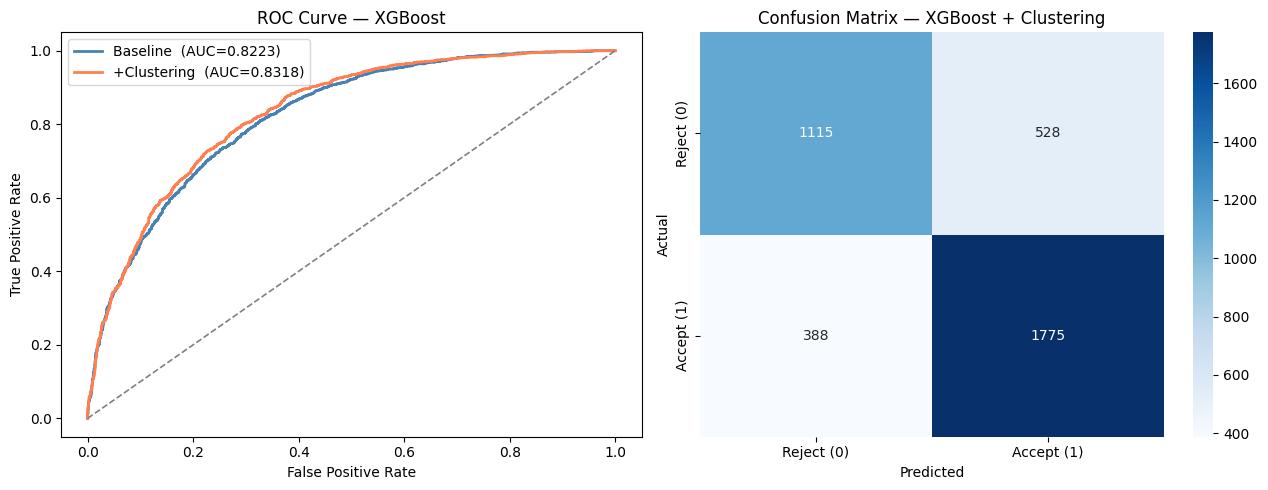

In [38]:
# ROC curves: baseline vs enhanced
fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_base_xgb)
fpr_c, tpr_c, _ = roc_curve(y_test, y_proba_cluster_xgb)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr_b, tpr_b, color='steelblue', lw=2, label=f'Baseline  (AUC={auc_base_xgb:.4f})')
axes[0].plot(fpr_c, tpr_c, color='coral',     lw=2, label=f'+Clustering  (AUC={auc_cluster_xgb:.4f})')
axes[0].plot([0,1],[0,1], color='gray', linestyle='--', lw=1.2)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — XGBoost')
axes[0].legend()

# Confusion matrix for best model (cluster)
cm = confusion_matrix(y_test, y_pred_cluster_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Reject (0)', 'Accept (1)'],
            yticklabels=['Reject (0)', 'Accept (1)'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix — XGBoost + Clustering')

plt.tight_layout()
plt.show()

#### Deep Dive of XGBoost

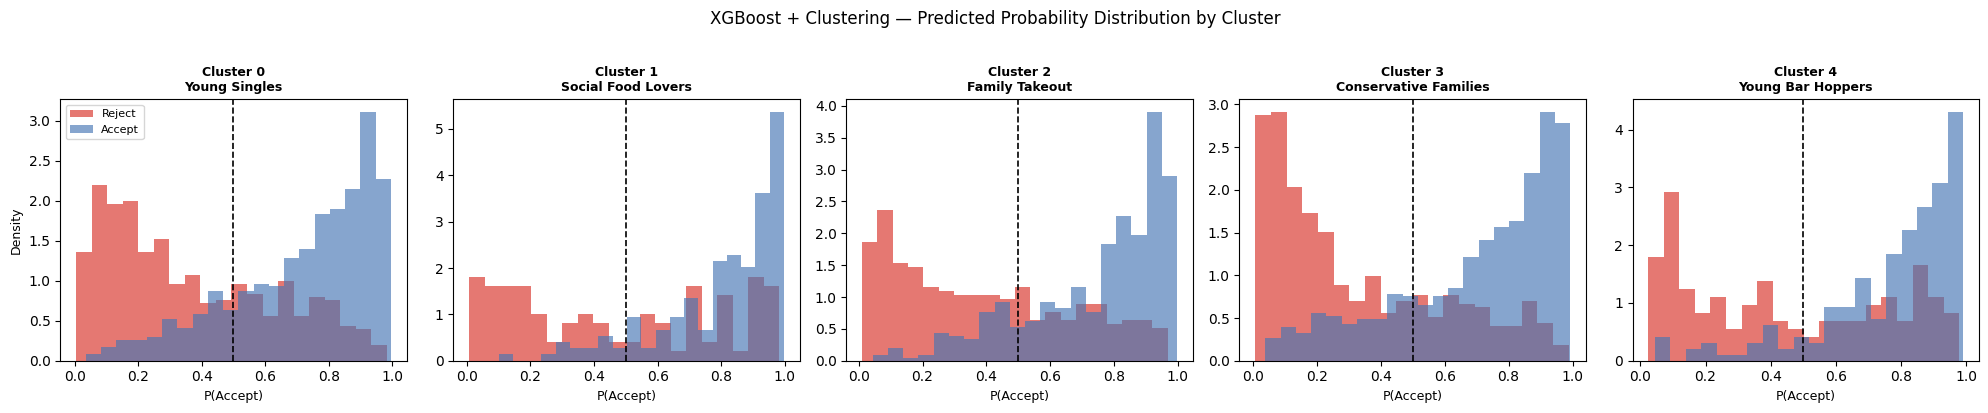

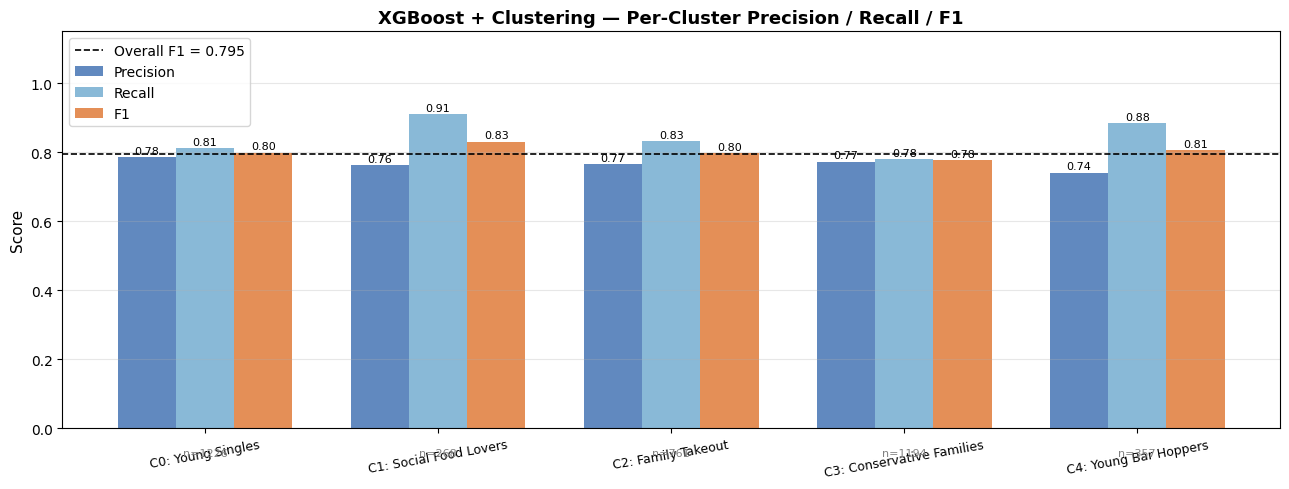

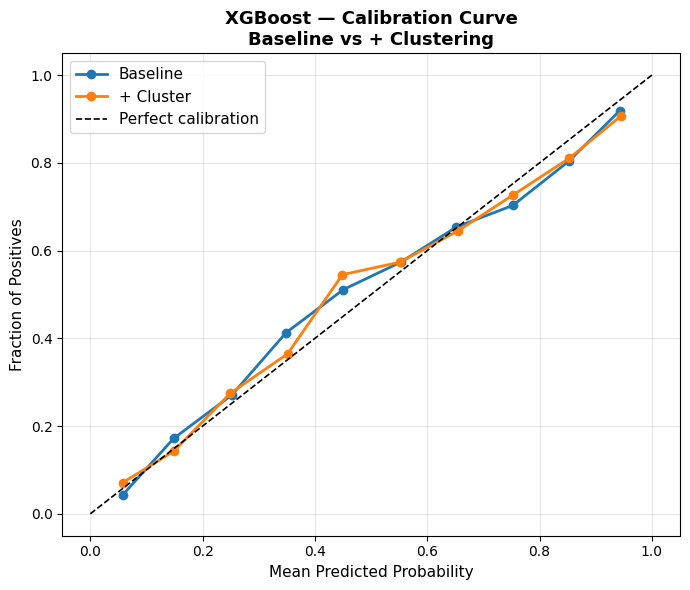

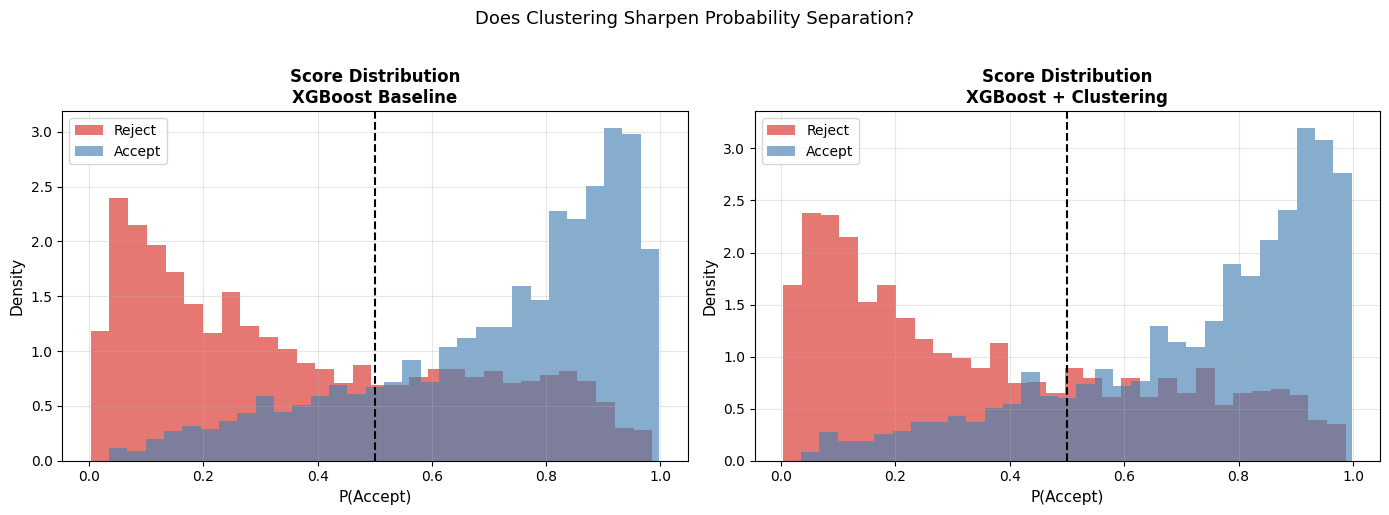

In [39]:
# ── XGBoost + Clustering Deep-Dive ──────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score
from sklearn.calibration import calibration_curve as cal_curve

cluster_label_map = {
    0: 'Young Singles',     1: 'Social Food Lovers',
    2: 'Family Takeout',    3: 'Conservative Families',
    4: 'Young Bar Hoppers',
}

# ── 1. Probability distribution by cluster ───────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)
for c in range(5):
    mask   = test_cluster_labels == c
    proba_c = y_proba_cluster_xgb[mask]
    true_c  = y_test.values[mask]
    axes[c].hist(proba_c[true_c == 0], bins=20, alpha=0.65,
                 color='#d73027', label='Reject', density=True)
    axes[c].hist(proba_c[true_c == 1], bins=20, alpha=0.65,
                 color='#4575b4', label='Accept', density=True)
    axes[c].axvline(0.5, color='black', lw=1.2, linestyle='--')
    axes[c].set_title(f'Cluster {c}\n{cluster_label_map[c]}', fontsize=9, fontweight='bold')
    axes[c].set_xlabel('P(Accept)', fontsize=9)
    if c == 0:
        axes[c].set_ylabel('Density', fontsize=9)
        axes[c].legend(fontsize=8)
plt.suptitle('XGBoost + Clustering — Predicted Probability Distribution by Cluster',
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

# ── 2. Per-cluster Precision / Recall / F1 ───────────────────────────────────
rows = []
for c in range(5):
    mask   = test_cluster_labels == c
    yt, yp = y_test.values[mask], y_pred_cluster_xgb[mask]
    rows.append({'Cluster': f'C{c}: {cluster_label_map[c]}',
                 'Precision': precision_score(yt, yp, zero_division=0),
                 'Recall':    recall_score(yt, yp, zero_division=0),
                 'F1':        f1_score(yt, yp, zero_division=0),
                 'Support':   mask.sum()})
cm_df = pd.DataFrame(rows)

x = np.arange(len(cm_df)); w = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w,   cm_df['Precision'], w, label='Precision', color='#4575b4', alpha=0.85)
ax.bar(x,       cm_df['Recall'],    w, label='Recall',    color='#74add1', alpha=0.85)
ax.bar(x + w,   cm_df['F1'],        w, label='F1',        color='#e07b39', alpha=0.85)
for j, row in cm_df.iterrows():
    for val, off in [(row['Precision'], -w), (row['Recall'], 0), (row['F1'], w)]:
        ax.text(j + off, val + 0.01, f'{val:.2f}', ha='center', fontsize=8)
    ax.text(j, -0.08, f"n={row['Support']}", ha='center', fontsize=8, color='gray')
ax.set_xticks(x)
ax.set_xticklabels(cm_df['Cluster'], fontsize=9, rotation=10)
ax.set_ylim(0, 1.15)
ax.axhline(f1_cluster_xgb, color='black', lw=1.2, linestyle='--',
           label=f'Overall F1 = {f1_cluster_xgb:.3f}')
ax.set_ylabel('Score', fontsize=11)
ax.set_title('XGBoost + Clustering — Per-Cluster Precision / Recall / F1',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# ── 3. Calibration: Baseline vs Enhanced ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
for lbl, prob in [('Baseline', y_proba_base_xgb), ('+ Cluster', y_proba_cluster_xgb)]:
    fp, mp = cal_curve(y_test, prob, n_bins=10, strategy='uniform')
    ax.plot(mp, fp, marker='o', lw=2, label=lbl)
ax.plot([0,1],[0,1], 'k--', lw=1.2, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Fraction of Positives', fontsize=11)
ax.set_title('XGBoost — Calibration Curve\nBaseline vs + Clustering',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── 4. Score distribution: Baseline vs Enhanced ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, prob, title, color in [
    (axes[0], y_proba_base_xgb,    'XGBoost Baseline',    'steelblue'),
    (axes[1], y_proba_cluster_xgb, 'XGBoost + Clustering', 'steelblue'),
]:
    ax.hist(prob[y_test == 0], bins=30, alpha=0.65, color='#d73027', label='Reject', density=True)
    ax.hist(prob[y_test == 1], bins=30, alpha=0.65, color=color,     label='Accept', density=True)
    ax.axvline(0.5, color='black', lw=1.5, linestyle='--')
    ax.set_xlabel('P(Accept)', fontsize=11); ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Score Distribution\n{title}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.suptitle('Does Clustering Sharpen Probability Separation?', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


#### Feature Importance

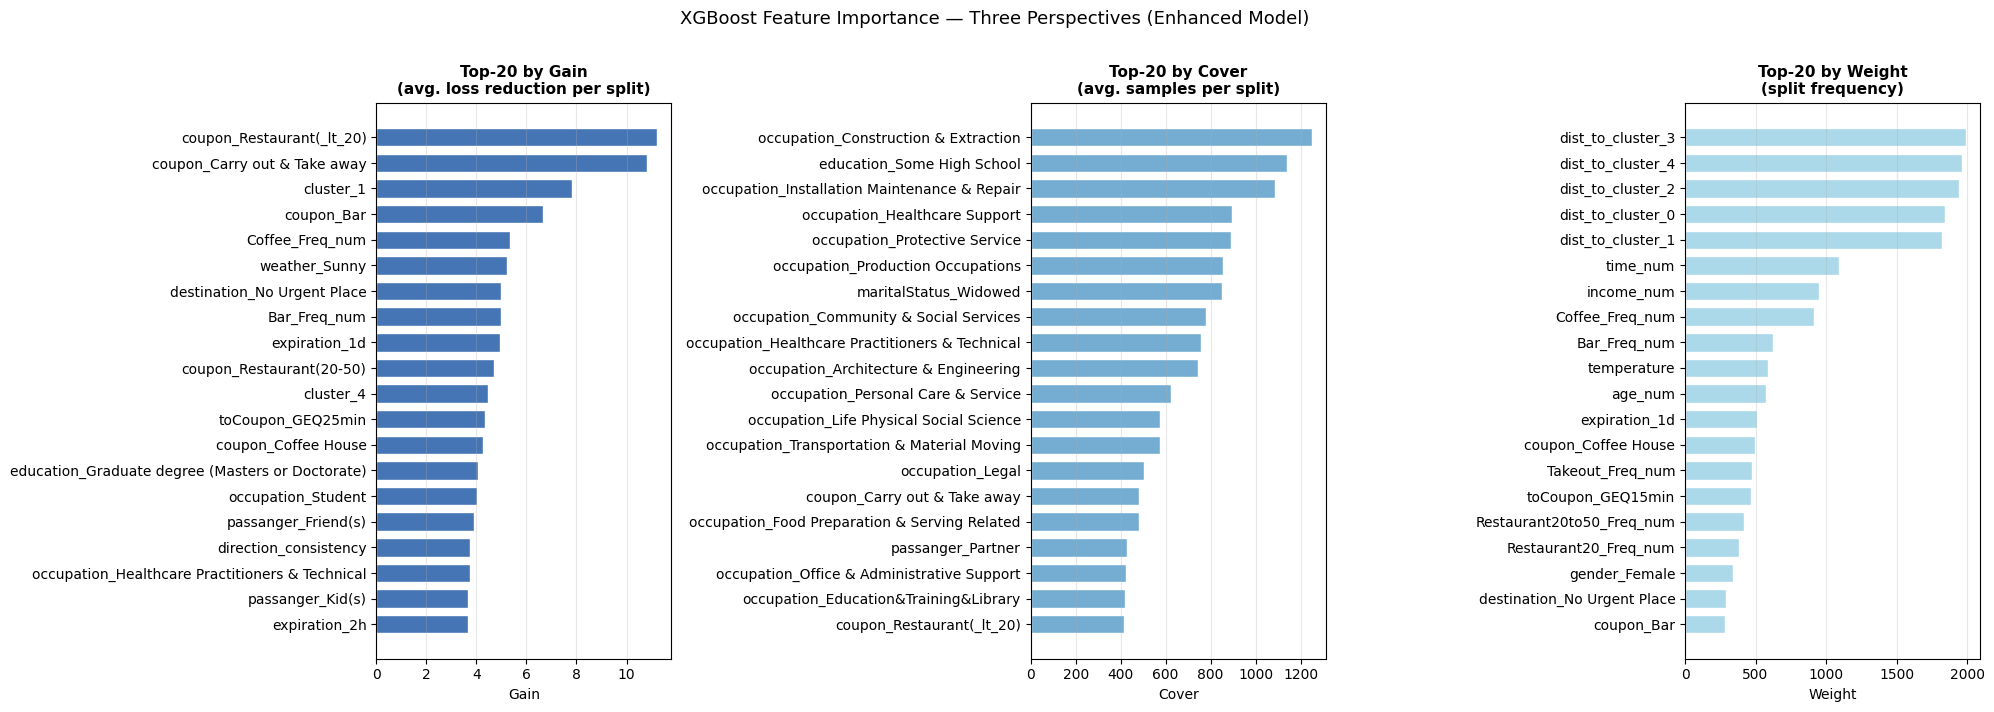

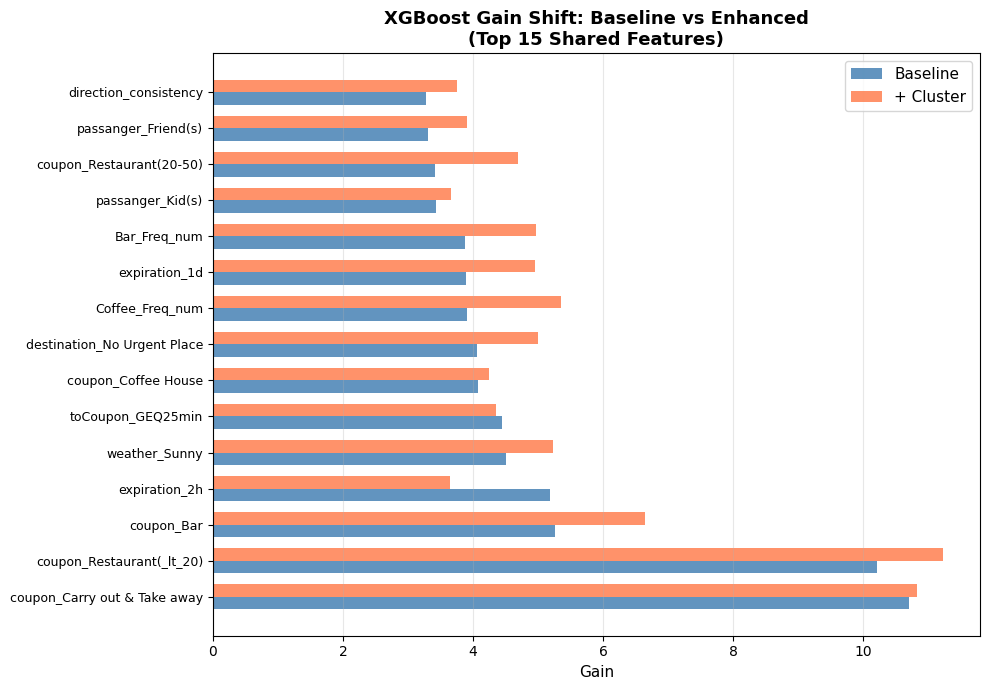

In [40]:
# ── XGBoost Feature Importance — All 3 Types + Shift Analysis ───────────────
raw_names_xgb = preprocessor.get_feature_names_out()
base_fn_xgb   = [n.split('__',1)[1].replace('<','_lt_').replace('>','_gt_')
                  .replace('[','_').replace(']','_') for n in raw_names_xgb]
k_val = 5
all_xgb_names = (base_fn_xgb
                 + [f'cluster_{j}' for j in range(k_val)]
                 + [f'dist_to_cluster_{j}' for j in range(k_val)])

def xgb_imp_df(model, feat_names, itype, topn=20):
    scores = model.get_booster().get_score(importance_type=itype)
    # Map f0,f1... indices if needed
    if scores and all(k.startswith('f') and k[1:].isdigit() for k in scores):
        scores = {feat_names[int(k[1:])]: v for k, v in scores.items()
                  if int(k[1:]) < len(feat_names)}
    df = pd.DataFrame({'Feature': list(scores.keys()), itype: list(scores.values())})
    return df.nlargest(topn, itype)

gain_df   = xgb_imp_df(xgb_cluster_model, all_xgb_names, 'gain')
cover_df  = xgb_imp_df(xgb_cluster_model, all_xgb_names, 'cover')
weight_df = xgb_imp_df(xgb_cluster_model, all_xgb_names, 'weight')

# ── 1. Three types side by side ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, df, col, subtitle, color in [
    (axes[0], gain_df,   'gain',   'avg. loss reduction per split', '#4575b4'),
    (axes[1], cover_df,  'cover',  'avg. samples per split',        '#74add1'),
    (axes[2], weight_df, 'weight', 'split frequency',               '#abd9e9'),
]:
    ax.barh(df['Feature'][::-1], df[col][::-1], color=color, edgecolor='white', height=0.72)
    ax.set_xlabel(col.capitalize(), fontsize=10)
    ax.set_title(f'Top-20 by {col.capitalize()}\n({subtitle})', fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
plt.suptitle('XGBoost Feature Importance — Three Perspectives (Enhanced Model)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

# ── 2. Gain shift: Baseline vs Enhanced ──────────────────────────────────────
gain_base = xgb_imp_df(xgb_base_model, base_fn_xgb, 'gain', topn=len(base_fn_xgb))
gain_enh  = xgb_imp_df(xgb_cluster_model, all_xgb_names, 'gain', topn=len(all_xgb_names))
gain_base.columns = ['Feature', 'Gain_Base']
gain_enh.columns  = ['Feature', 'Gain_Enh']
gain_shift = gain_base.merge(gain_enh, on='Feature').nlargest(15, 'Gain_Base')

x = np.arange(len(gain_shift)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(x - w/2, gain_shift['Gain_Base'], w, label='Baseline',  color='steelblue', alpha=0.85)
ax.barh(x + w/2, gain_shift['Gain_Enh'],  w, label='+ Cluster', color='coral',     alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(gain_shift['Feature'], fontsize=9)
ax.set_xlabel('Gain', fontsize=11)
ax.set_title('XGBoost Gain Shift: Baseline vs Enhanced\n(Top 15 Shared Features)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


#### SHAP Beeswarm of XGBoost + Clustering

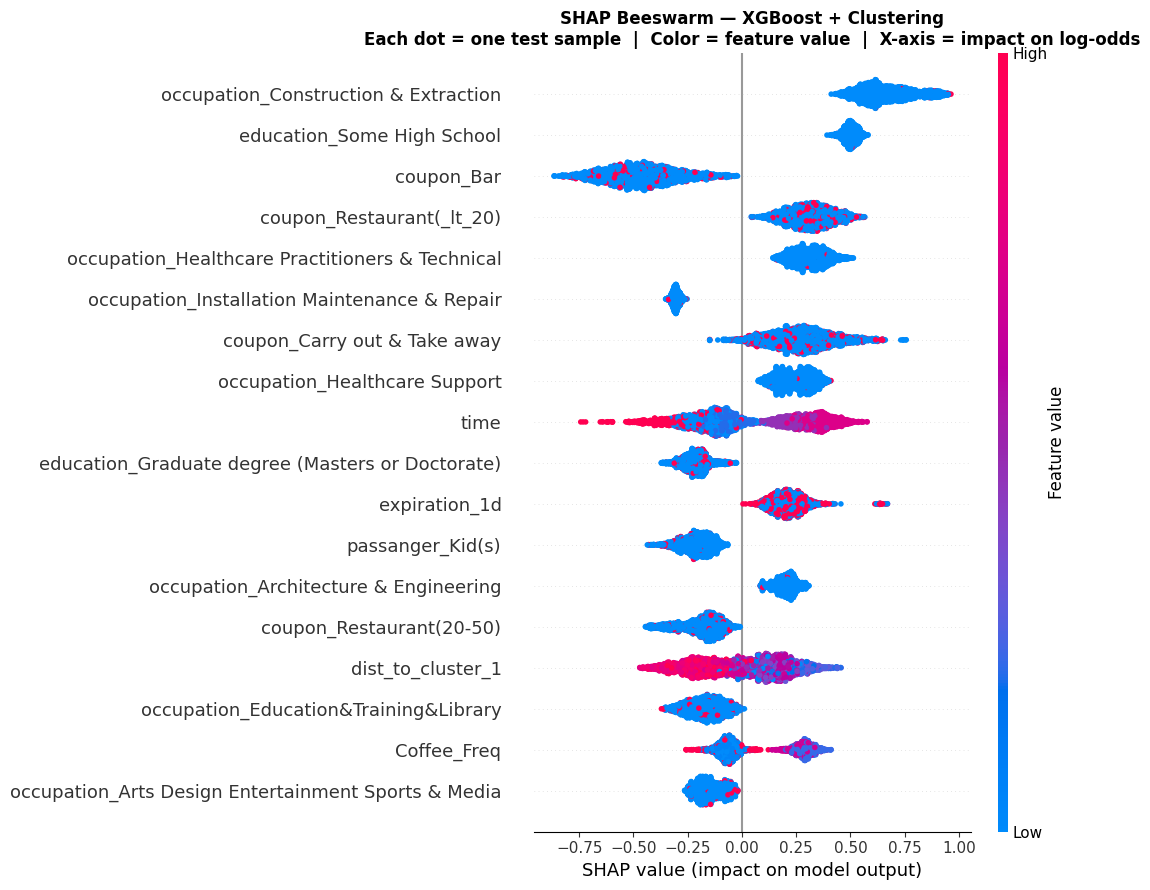

In [41]:
# ── SHAP Comprehensive Suite ─────────────────────────────────────────────────
if SHAP_AVAILABLE:
    X_test_cluster_df = pd.DataFrame(
        X_test_cluster.toarray(), columns=cluster_feature_names
    )
    explainer   = shap.TreeExplainer(xgb_cluster_model)
    shap_values = explainer.shap_values(X_test_cluster_df)
    shap_exp    = explainer(X_test_cluster_df)  # Explanation object for waterfall

    # Clean display names (strip transformer prefixes)
    clean_names = [n.replace('num__','').replace('cat__','').replace('_num','')
                   for n in cluster_feature_names]
    X_test_disp = X_test_cluster_df.copy()
    X_test_disp.columns = clean_names
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    # ── Beeswarm ───────────────────────────────────────────────────────────
    plt.figure(figsize=(11, 9))
    shap.summary_plot(shap_values, X_test_disp, show=False, max_display=18, plot_size=None)
    plt.title('SHAP Beeswarm — XGBoost + Clustering\n'
              'Each dot = one test sample  |  Color = feature value  |  X-axis = impact on log-odds',
              fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

else:
    print('Install SHAP: pip install shap')


### 4.4 Cross-Model Analysis

#### Feature Importance of Each Model

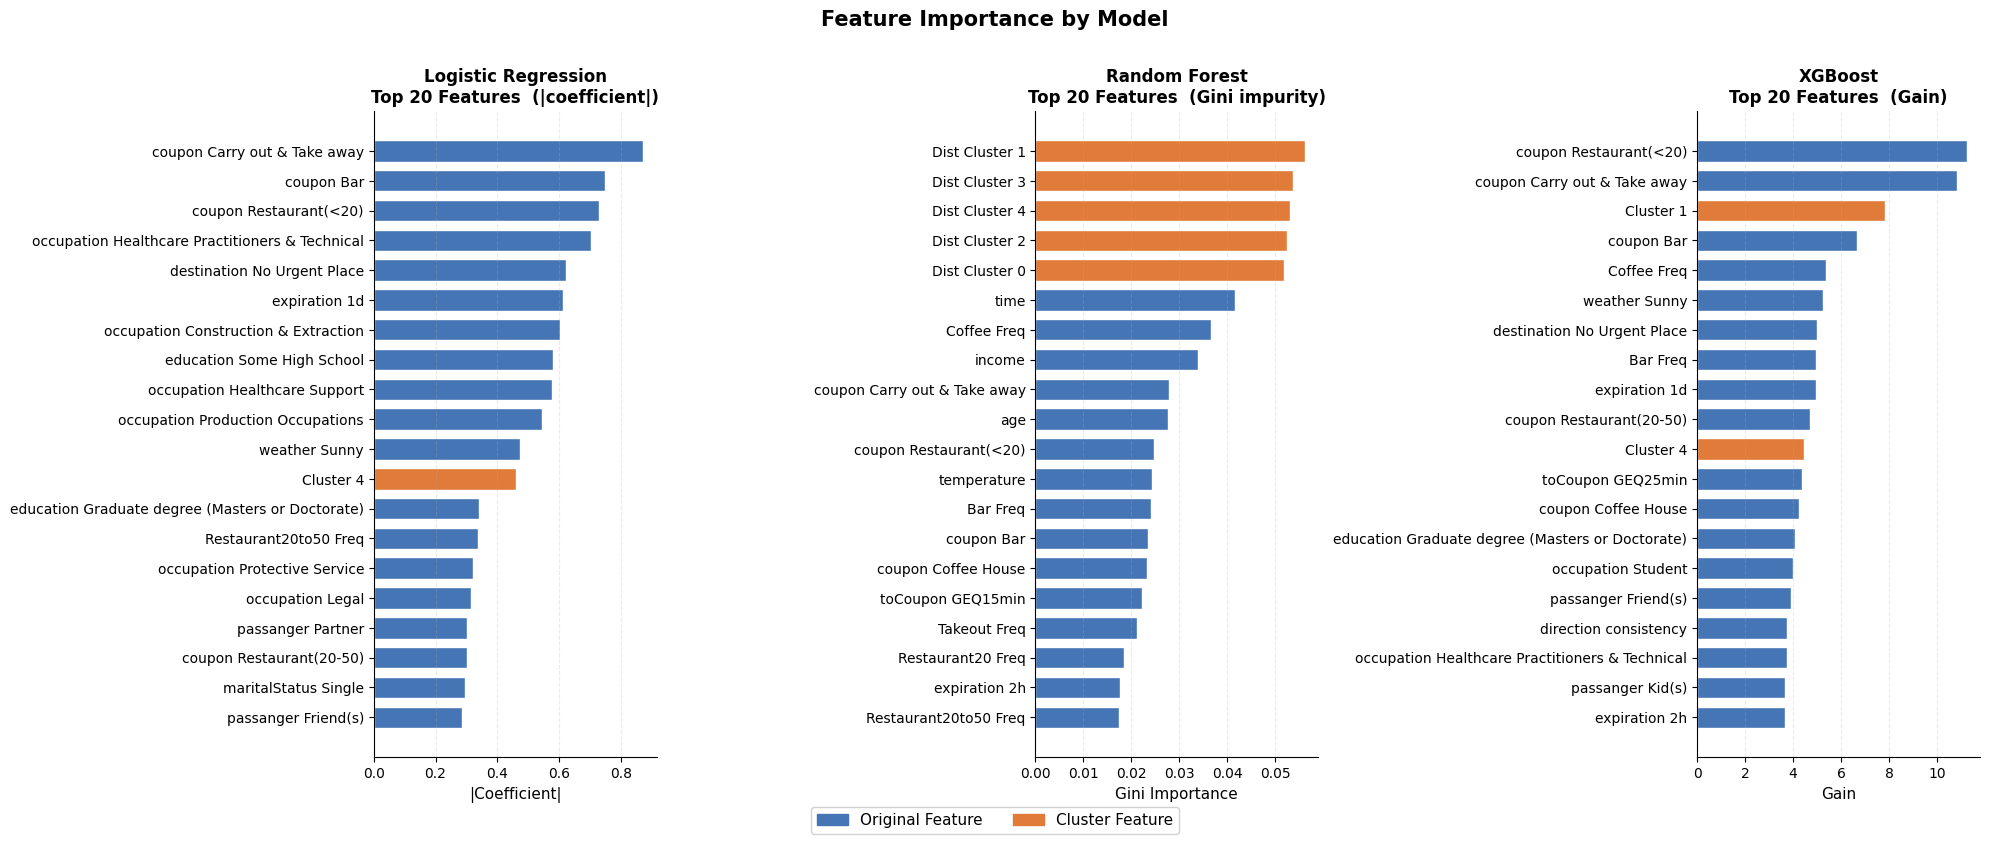

In [42]:
# ── Feature Importance — 3 Separate Charts (one per model) ──────────────────
import matplotlib.patches as mpatches

# ── Shared setup ──────────────────────────────────────────────────────────────
base_feat_names    = list(preprocessor.get_feature_names_out())
cluster_ohe_names  = [f'Cluster_{i}' for i in range(5)]
cluster_dist_names = [f'Dist_Cluster_{i}' for i in range(5)]
all_feat_names     = base_feat_names + cluster_ohe_names + cluster_dist_names

def clean(name):
    return (name.replace('num__','').replace('cat__','')
                .replace('_num','').replace('_',' ').strip())
clean_names = [clean(n) for n in all_feat_names]

def is_cluster(name):
    nl = name.lower()
    return 'cluster' in nl or 'dist' in nl

COLOR_ORIG    = '#4575b4'
COLOR_CLUSTER = '#e07b39'

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Feature Importance by Model', fontsize=15, fontweight='bold', y=1.01)

# ── 1. Logistic Regression — |coefficient| ───────────────────────────────────
lr_coefs = np.abs(lr_enhanced.coef_[0])
lr_df = pd.DataFrame({'Feature': clean_names, 'Importance': lr_coefs})
lr_top = lr_df.nlargest(20, 'Importance').sort_values('Importance', ascending=True)

colors_lr = [COLOR_CLUSTER if is_cluster(f) else COLOR_ORIG for f in lr_top['Feature']]
axes[0].barh(lr_top['Feature'], lr_top['Importance'],
             color=colors_lr, edgecolor='white', height=0.72)
axes[0].set_xlabel('|Coefficient|', fontsize=11)
axes[0].set_title('Logistic Regression\nTop 20 Features  (|coefficient|)',
                  fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.25, linestyle='--')
axes[0].spines[['top','right']].set_visible(False)

# ── 2. Random Forest — Gini impurity ─────────────────────────────────────────
rf_imp = rf_cluster_model.feature_importances_
rf_df  = pd.DataFrame({'Feature': clean_names, 'Importance': rf_imp})
rf_top = rf_df.nlargest(20, 'Importance').sort_values('Importance', ascending=True)

colors_rf = [COLOR_CLUSTER if is_cluster(f) else COLOR_ORIG for f in rf_top['Feature']]
axes[1].barh(rf_top['Feature'], rf_top['Importance'],
             color=colors_rf, edgecolor='white', height=0.72)
axes[1].set_xlabel('Gini Importance', fontsize=11)
axes[1].set_title('Random Forest\nTop 20 Features  (Gini impurity)',
                  fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.25, linestyle='--')
axes[1].spines[['top','right']].set_visible(False)

# ── 3. XGBoost — Gain ────────────────────────────────────────────────────────
raw_xgb     = preprocessor.get_feature_names_out()
base_fn_xgb = [n.split('__',1)[1].replace('<','_lt_').replace('>','_gt_')
                .replace('[','_').replace(']','_') for n in raw_xgb]
all_xgb_keys = base_fn_xgb + [f'cluster_{j}' for j in range(5)] + [f'dist_to_cluster_{j}' for j in range(5)]

scores = xgb_cluster_model.get_booster().get_score(importance_type='gain')
if scores and all(k.startswith('f') and k[1:].isdigit() for k in scores):
    scores = {all_xgb_keys[int(k[1:])]: v for k, v in scores.items()
              if int(k[1:]) < len(all_xgb_keys)}
xgb_vals = [scores.get(k, 0) for k in all_xgb_keys]
xgb_df = pd.DataFrame({'Feature': clean_names, 'Importance': xgb_vals})
xgb_top = xgb_df.nlargest(20, 'Importance').sort_values('Importance', ascending=True)

colors_xgb = [COLOR_CLUSTER if is_cluster(f) else COLOR_ORIG for f in xgb_top['Feature']]
axes[2].barh(xgb_top['Feature'], xgb_top['Importance'],
             color=colors_xgb, edgecolor='white', height=0.72)
axes[2].set_xlabel('Gain', fontsize=11)
axes[2].set_title('XGBoost\nTop 20 Features  (Gain)',
                  fontsize=12, fontweight='bold')
axes[2].grid(axis='x', alpha=0.25, linestyle='--')
axes[2].spines[['top','right']].set_visible(False)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=COLOR_ORIG,    label='Original Feature'),
    mpatches.Patch(color=COLOR_CLUSTER, label='Cluster Feature'),
]
fig.legend(handles=legend_handles, fontsize=11, loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.03),
           framealpha=0.9, edgecolor='#cccccc')

plt.tight_layout()
plt.show()


#### Cross-Model Feature Importance Comparison

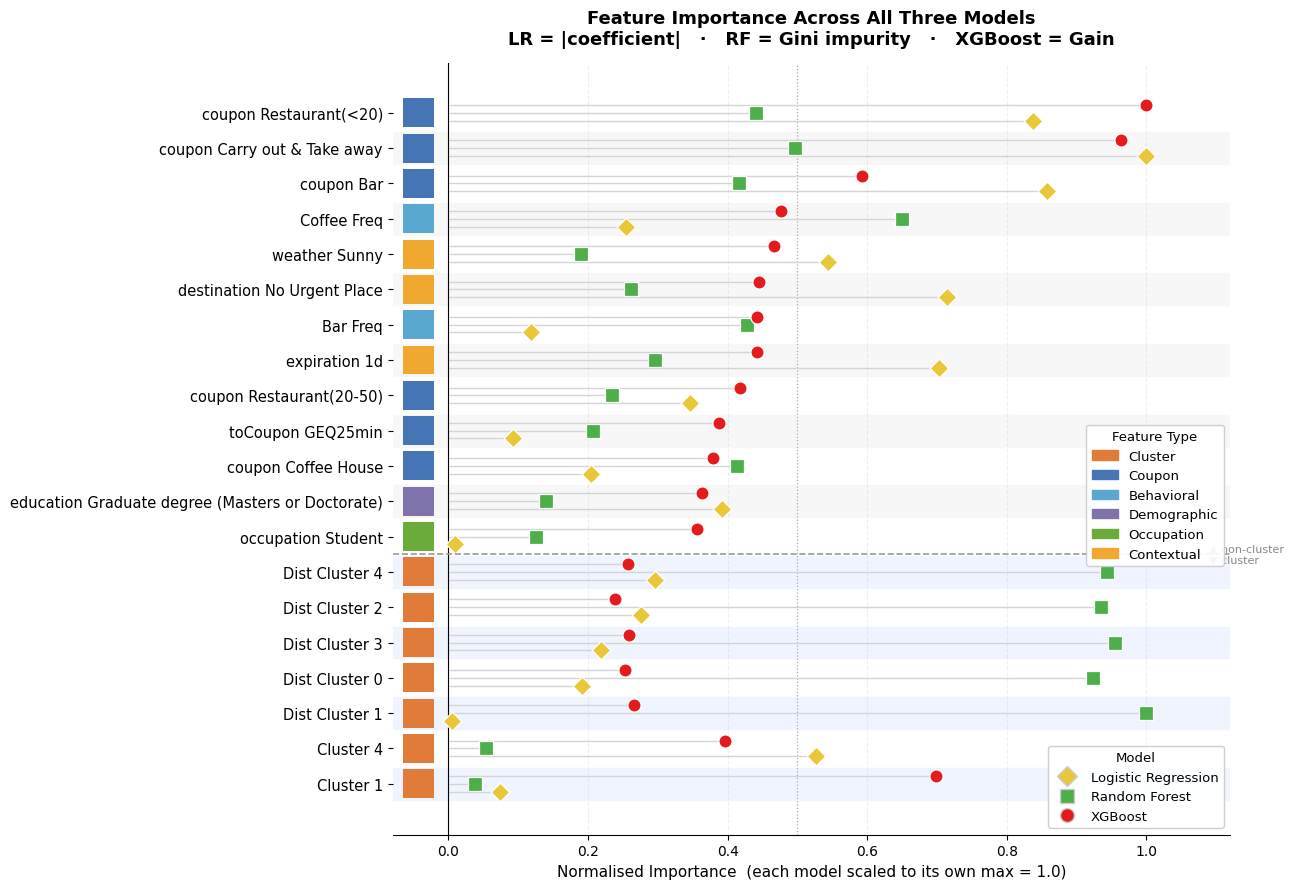

In [43]:
# ── Cross-Model Feature Importance Comparison ────────────────────────────────
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Feature name setup ────────────────────────────────────────────────────────
base_feat_names    = list(preprocessor.get_feature_names_out())
cluster_ohe_names  = [f'Cluster_{i}' for i in range(5)]
cluster_dist_names = [f'Dist_Cluster_{i}' for i in range(5)]
all_feat_names     = base_feat_names + cluster_ohe_names + cluster_dist_names

def clean(name):
    return (name.replace('num__','').replace('cat__','')
                .replace('_num','').replace('_',' ').strip())
clean_names = [clean(n) for n in all_feat_names]

# ── LR: normalised absolute coefficients ─────────────────────────────────────
lr_coefs = np.abs(lr_enhanced.coef_[0])
lr_df = pd.DataFrame({'Feature': clean_names, 'LR': lr_coefs / lr_coefs.max()})

# ── RF: normalised gini importance ───────────────────────────────────────────
rf_imp = rf_cluster_model.feature_importances_
rf_df  = pd.DataFrame({'Feature': clean_names, 'RF': rf_imp / rf_imp.max()})

# ── XGBoost: normalised gain importance ──────────────────────────────────────
raw_xgb     = preprocessor.get_feature_names_out()
base_fn_xgb = [n.split('__',1)[1].replace('<','_lt_').replace('>','_gt_')
                .replace('[','_').replace(']','_') for n in raw_xgb]
all_xgb_keys = base_fn_xgb + [f'cluster_{j}' for j in range(5)] + [f'dist_to_cluster_{j}' for j in range(5)]

scores = xgb_cluster_model.get_booster().get_score(importance_type='gain')
if scores and all(k.startswith('f') and k[1:].isdigit() for k in scores):
    scores = {all_xgb_keys[int(k[1:])]: v for k, v in scores.items()
              if int(k[1:]) < len(all_xgb_keys)}
xgb_vals = np.array([scores.get(k, 0) for k in all_xgb_keys], dtype=float)
xgb_df = pd.DataFrame({'Feature': clean_names, 'XGB': xgb_vals / (xgb_vals.max() + 1e-9)})

# ── Merge, tag feature types ──────────────────────────────────────────────────
merged = lr_df.merge(rf_df, on='Feature').merge(xgb_df, on='Feature')
merged['Mean'] = merged[['LR','RF','XGB']].mean(axis=1)

def tag(f):
    fl = f.lower()
    if 'cluster' in fl or 'dist' in fl:   return 'Cluster'
    if 'coupon' in fl:                     return 'Coupon'
    if 'occupation' in fl:                 return 'Occupation'
    if any(x in fl for x in ['freq','bar ','coffee','takeout','restaurant']): return 'Behavioral'
    if any(x in fl for x in ['age','income','children','gender','marital','education']): return 'Demographic'
    return 'Contextual'

merged['Type'] = merged['Feature'].apply(tag)

# ── Sort: cluster features grouped at bottom, non-cluster sorted by XGB desc ──
cluster_mask = merged['Type'] == 'Cluster'
non_cluster  = merged[~cluster_mask].nlargest(13, 'XGB').sort_values('XGB', ascending=True)
cluster_rows = merged[cluster_mask].nlargest(7, 'Mean').sort_values('Mean', ascending=True)
top = pd.concat([cluster_rows, non_cluster]).reset_index(drop=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
TYPE_COLORS = {
    'Cluster':    '#e07b39',
    'Coupon':     '#4575b4',
    'Behavioral': '#5aa8d0',
    'Demographic':'#8073ac',
    'Occupation': '#6aab3a',
    'Contextual': '#f0a830',
}

fig, ax = plt.subplots(figsize=(13, 9))
y_pos = np.arange(len(top))

# Cluster group separator
n_cluster = len(cluster_rows)
ax.axhline(n_cluster - 0.5, color='#999999', lw=1.2, linestyle='--', zorder=4)
ax.text(1.09, n_cluster - 0.5, '▲ non-cluster\n▼ cluster', fontsize=8,
        color='#888888', va='center', ha='left')

# Alternating row shading (blue tint for cluster section)
for j in range(len(top)):
    c = '#f0f4ff' if top.loc[j,'Type'] == 'Cluster' else '#f7f7f7'
    if j % 2 == 0:
        ax.axhspan(j - 0.45, j + 0.45, color=c, zorder=0)

# Feature-type colour strip
for j, row in top.iterrows():
    ax.barh(j, 0.045, left=-0.065, height=0.82,
            color=TYPE_COLORS.get(row['Type'], '#cccccc'),
            zorder=2, clip_on=False)

# Reference line at 0.5
ax.axvline(0.5, color='#aaaaaa', lw=0.9, linestyle=':', zorder=1)

# Lollipops
offsets = {'LR': -0.22, 'RF': 0.0,  'XGB':  0.22}
markers = {'LR': 'D',   'RF': 's',  'XGB':  'o'}
fills   = {'LR': '#e8c838', 'RF': '#4daf4a', 'XGB': '#e41a1c'}

for model, offset in offsets.items():
    ys = y_pos + offset
    xs = top[model].values
    for y_i, x_i in zip(ys, xs):
        ax.plot([0, x_i], [y_i, y_i], color='#d5d5d5', lw=1.0, zorder=1)
    ax.scatter(xs, ys, s=90, marker=markers[model],
               color=fills[model], edgecolors='white',
               linewidths=0.9, zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(top['Feature'], fontsize=10.5)
ax.set_xlabel('Normalised Importance  (each model scaled to its own max = 1.0)', fontsize=11)
ax.set_title('Feature Importance Across All Three Models\n'
             'LR = |coefficient|   ·   RF = Gini impurity   ·   XGBoost = Gain',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlim(-0.08, 1.12)
ax.axvline(0, color='black', lw=0.8)
ax.grid(axis='x', alpha=0.2, linestyle='--')
ax.spines[['top','right','left']].set_visible(False)

model_handles = [
    Line2D([0],[0], marker='D', color='w', markerfacecolor='#e8c838',
           markeredgecolor='#cccccc', markersize=10, label='Logistic Regression'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#4daf4a',
           markeredgecolor='#cccccc', markersize=10, label='Random Forest'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#e41a1c',
           markeredgecolor='#cccccc', markersize=10, label='XGBoost'),
]
type_handles = [mpatches.Patch(color=c, label=t)
                for t, c in TYPE_COLORS.items()
                if t in top['Type'].values]

leg1 = ax.legend(handles=model_handles, title='Model', fontsize=9.5,
                 title_fontsize=9.5, loc='lower right', framealpha=0.93,
                 edgecolor='#cccccc', bbox_to_anchor=(1.0, 0.0))
ax.add_artist(leg1)
ax.legend(handles=type_handles, title='Feature Type', fontsize=9.5,
          title_fontsize=9.5, loc='center right', framealpha=0.93,
          edgecolor='#cccccc', bbox_to_anchor=(1.0, 0.44))

plt.tight_layout()
plt.show()


#### Model Performance Table

In [44]:
# ── Model comparison table ───────────────────────────────────────────────
results = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Logistic Regression + Clustering', 'Random Forest', 'Random Forest + Clustering', 'XGBoost', 'XGBoost + Clustering'],
    'Test AUC': [base_auc, enh_auc, auc_base_rf, auc_cluster_rf, auc_base_xgb, auc_cluster_xgb],
    'Test F1':  [base_f1,  enh_f1,  f1_base_rf,  f1_cluster_rf,  f1_base_xgb,  f1_cluster_xgb],
})
print(results.to_string(index=False))


                           Model  Test AUC  Test F1
             Logistic Regression  0.722782 0.730228
Logistic Regression + Clustering  0.724297 0.731441
                   Random Forest  0.806099 0.786378
      Random Forest + Clustering  0.815624 0.793903
                         XGBoost  0.822298 0.787010
            XGBoost + Clustering  0.831769 0.794895


---
## Part 5 · Prescriptive Analysis & Business Strategy

### 5.1 Cluster x Coupon Type targeting matrix

In [45]:
# ── Cluster profile table ────────────────────────────────────────────────
cluster_labels = {
    0: 'Young Singles',
    1: 'Social Food Lovers',
    2: 'Family Takeout',
    3: 'Conservative Families',
    4: 'Young Bar Hoppers',
}

display_profile = profile.copy()
display_profile.index = [f'Cluster {i} — {cluster_labels[i]}' for i in display_profile.index]
display_profile.columns = ['Count', 'Accept Rate', 'Age', 'Income', 'Has Children',
                            'Bar Freq', 'CoffeeHouse Freq', 'Takeout Freq',
                            'Restaurant<20 Freq', 'Restaurant20-50 Freq']

display(display_profile.style
        .format({'Accept Rate': '{:.1%}', 'Income': '${:,.0f}',
                 'Age': '{:.1f}', 'Count': '{:.0f}'})
        .background_gradient(subset=['Accept Rate'], cmap='RdYlGn')
        .set_caption('Cluster Profile Summary'))

,Count,Accept Rate,Age,Income,Has Children,Bar Freq,CoffeeHouse Freq,Takeout Freq,Restaurant<20 Freq,Restaurant20-50 Freq
Cluster 0 — Young Singles,2746,57.0%,25.6,"$45,916",0.000000,0.600000,1.520000,2.800000,2.290000,0.720000
Cluster 1 — Social Food Lovers,658,66.0%,30.9,"$59,077",0.370000,2.950000,4.630000,5.620000,6.770000,6.850000
Cluster 2 — Family Takeout,1801,58.0%,33.9,"$63,198",0.430000,0.720000,3.550000,6.730000,6.320000,0.980000
Cluster 3 — Conservative Families,2891,51.0%,41.7,"$54,012",0.890000,0.440000,1.480000,2.710000,2.140000,0.870000
Cluster 4 — Young Bar Hoppers,782,67.0%,27.4,"$52,769",0.140000,6.570000,3.050000,4.740000,4.190000,1.040000


In [46]:
# Load original df (with categorical columns like time, coupon) and attach cluster labels
# from the KMeans model trained in Part 3 — NO re-running KMeans here.
df_presc = pd.read_csv('../data/in-vehicle-coupon-dataset.csv')
if "car" in df_presc.columns:
    df_presc = df_presc.drop(columns=["car"])

# Assign cluster labels by index (X_train / X_test share index with original df)
df_presc["cluster"] = -1
df_presc.loc[X_train.index, "cluster"] = train_cluster_labels.astype(int)
df_presc.loc[X_test.index,  "cluster"] = test_cluster_labels.astype(int)

cluster_names = {
    0: "Young Singles",
    1: "Social Food Lovers",
    2: "Family Takeout",
    3: "Conservative Families",
    4: "Young Bar Hoppers",
}
cluster_colors = {
    0: "#1B6B93",
    1: "#2AAA6A",
    2: "#7B6FB5",
    3: "#8896A6",
    4: "#E8833A",
}

print("Rows with cluster label:", (df_presc["cluster"] >= 0).sum())
print(df_presc["cluster"].value_counts().sort_index())


Rows with cluster label: 12684
cluster
0    3972
1     926
2    2562
3    4085
4    1139
Name: count, dtype: int64


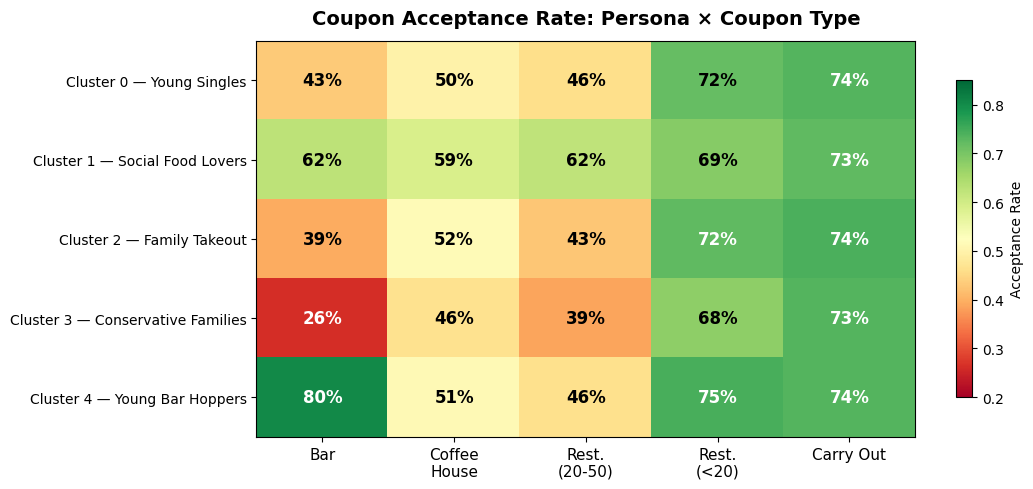

In [47]:
# ── Cluster × coupon acceptance rate heatmap ─────────────────────────────────
coupon_order = ["Bar", "Coffee House", "Restaurant(20-50)", "Restaurant(<20)", "Carry out & Take away"]
coupon_labels = ["Bar", "Coffee\nHouse", "Rest.\n(20-50)", "Rest.\n(<20)", "Carry Out"]

ct = df_presc.pivot_table(index="cluster", columns="coupon", values="Y", aggfunc="mean")

fig, ax = plt.subplots(figsize=(11, 5))
data = ct.reindex(index=range(5), columns=coupon_order)

im = ax.imshow(data.values, cmap="RdYlGn", aspect="auto", vmin=0.2, vmax=0.85)
ax.set_xticks(range(len(coupon_order)))
ax.set_xticklabels(coupon_labels, fontsize=11)
ax.set_yticks(range(5))
ax.set_yticklabels([f"Cluster {i} — {cluster_names[i]}" for i in range(5)], fontsize=10)

for i in range(5):
    for j in range(len(coupon_order)):
        val = data.values[i, j]
        color = "white" if (val < 0.35 or val > 0.72) else "black"
        ax.text(j, i, f"{val:.0%}", ha="center", va="center",
                fontsize=12, fontweight="bold", color=color)

plt.colorbar(im, ax=ax, label="Acceptance Rate", shrink=0.8)
ax.set_title("Coupon Acceptance Rate: Persona × Coupon Type", fontsize=14,
             fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


### 5.2 Timing Analysis & Strategy

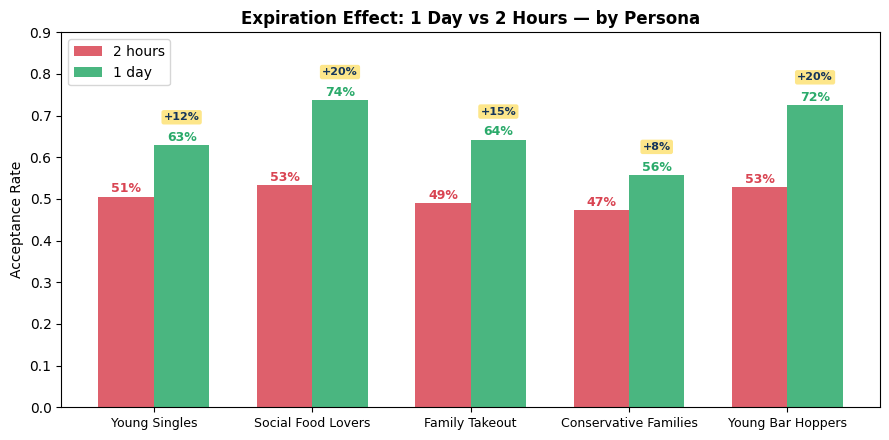

In [48]:
# ── Expiration Effect: 1 day vs 2 hours by cluster ──────────────────────────
exp = df_presc.pivot_table(index="cluster", columns="expiration", values="Y", aggfunc="mean")

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(5)
w = 0.35

bars1 = ax.bar(x - w/2, exp["2h"].values,  w, label="2 hours", color="#D94452", alpha=0.85)
bars2 = ax.bar(x + w/2, exp["1d"].values, w, label="1 day",   color="#2AAA6A", alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.0%}", ha="center", fontsize=9, color="#D94452", fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.0%}", ha="center", fontsize=9, color="#2AAA6A", fontweight="bold")

for i in range(5):
    lift = exp["1d"].values[i] - exp["2h"].values[i]
    ax.annotate(f"+{lift:.0%}", xy=(x[i] + w/2, exp["1d"].values[i] + 0.06),
                fontsize=8, ha="center", color="#14345B", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="#FDE68A", edgecolor="none"))

ax.set_xticks(x)
ax.set_xticklabels([cluster_names[i] for i in range(5)], fontsize=9)
ax.set_ylabel("Acceptance Rate")
ax.set_ylim(0, 0.9)
ax.set_title("Expiration Effect: 1 Day vs 2 Hours — by Persona", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Recommendation: 1-day coupons consistently outperform 2-hour across all clusters.
# Recommendation: Consider sending 1-day coupons as default, especially for Bar and Coffee House.


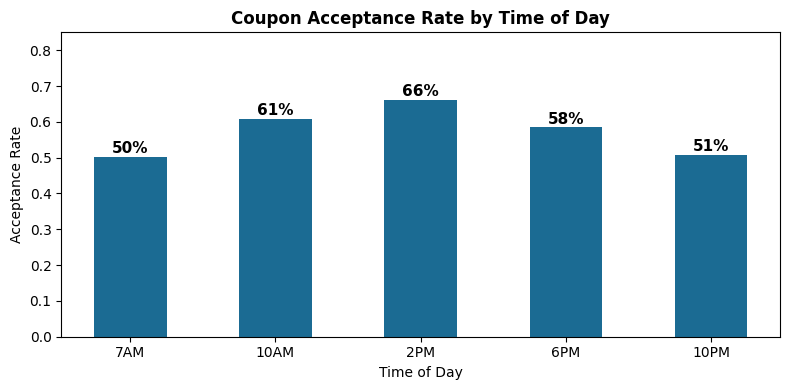

In [49]:
# ── Acceptance rate by time of day ──────────────────────────────────────────
time_order   = ["7AM", "10AM", "2PM", "6PM", "10PM"]
time_accept  = df_presc.groupby("time")["Y"].mean().reindex(time_order)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(time_accept.index, time_accept.values, color="#1B6B93", width=0.5)
for bar, val in zip(bars, time_accept.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.0%}", ha="center", fontweight="bold", fontsize=11)
ax.set_xlabel("Time of Day")
ax.set_ylabel("Acceptance Rate")
ax.set_title("Coupon Acceptance Rate by Time of Day", fontweight="bold")
ax.set_ylim(0, 0.85)
plt.tight_layout()
plt.show()


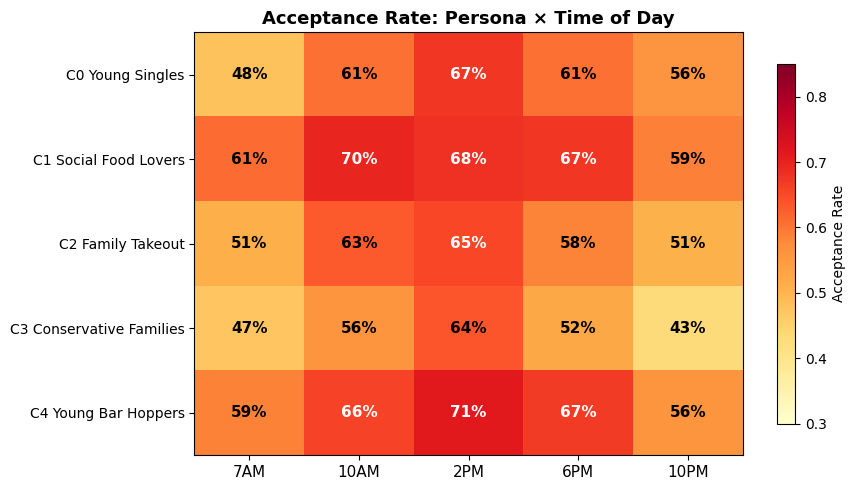

In [50]:
# ── Persona × Time heatmap ───────────────────────────────────────────────────
ct_time = df_presc.pivot_table(index="cluster", columns="time", values="Y", aggfunc="mean")
ct_time = ct_time.reindex(columns=time_order)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(ct_time.values, cmap="YlOrRd", aspect="auto", vmin=0.3, vmax=0.85)
ax.set_xticks(range(len(time_order)))
ax.set_xticklabels(time_order, fontsize=11)
ax.set_yticks(range(5))
ax.set_yticklabels([f"C{i} {cluster_names[i]}" for i in range(5)], fontsize=10)
for i in range(5):
    for j in range(len(time_order)):
        val = ct_time.values[i, j]
        ax.text(j, i, f"{val:.0%}", ha="center", va="center",
                color="white" if val > 0.65 else "black", fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax, label="Acceptance Rate", shrink=0.85)
ax.set_title("Acceptance Rate: Persona × Time of Day", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


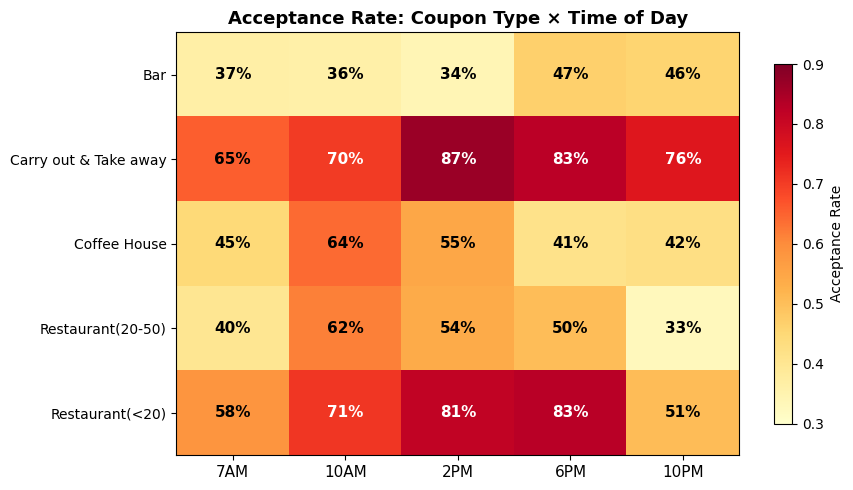

In [51]:
# ── Coupon × Time heatmap ────────────────────────────────────────────────────
ct_coupon_time = df_presc.pivot_table(index="coupon", columns="time", values="Y", aggfunc="mean")
ct_coupon_time = ct_coupon_time.reindex(columns=time_order)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(ct_coupon_time.values, cmap="YlOrRd", aspect="auto", vmin=0.3, vmax=0.9)
ax.set_xticks(range(len(time_order)))
ax.set_xticklabels(time_order, fontsize=11)
ax.set_yticks(range(len(ct_coupon_time.index)))
ax.set_yticklabels(ct_coupon_time.index, fontsize=10)
for i in range(len(ct_coupon_time.index)):
    for j in range(len(time_order)):
        val = ct_coupon_time.values[i, j]
        ax.text(j, i, f"{val:.0%}", ha="center", va="center",
                color="white" if val > 0.70 else "black", fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax, label="Acceptance Rate", shrink=0.85)
ax.set_title("Acceptance Rate: Coupon Type × Time of Day", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [52]:
# ── Best send time by coupon type ───────────────────────────────────────────
best_time = ct_coupon_time.idxmax(axis=1)
best_rate = ct_coupon_time.max(axis=1)

timing_df = pd.DataFrame({
    "Coupon Type":   best_time.index,
    "Best Send Time": best_time.values,
    "Peak Accept Rate": [f"{v:.0%}" for v in best_rate.values],
})
display(timing_df.set_index("Coupon Type"))

,Best Send Time,Peak Accept Rate
Coupon Type,,
Bar,6PM,47%
Carry out & Take away,2PM,87%
Coffee House,10AM,64%
Restaurant(20-50),10AM,62%
Restaurant(<20),6PM,83%


### 5.3 Scenario Analysis: Targeted vs Blanket Delivery

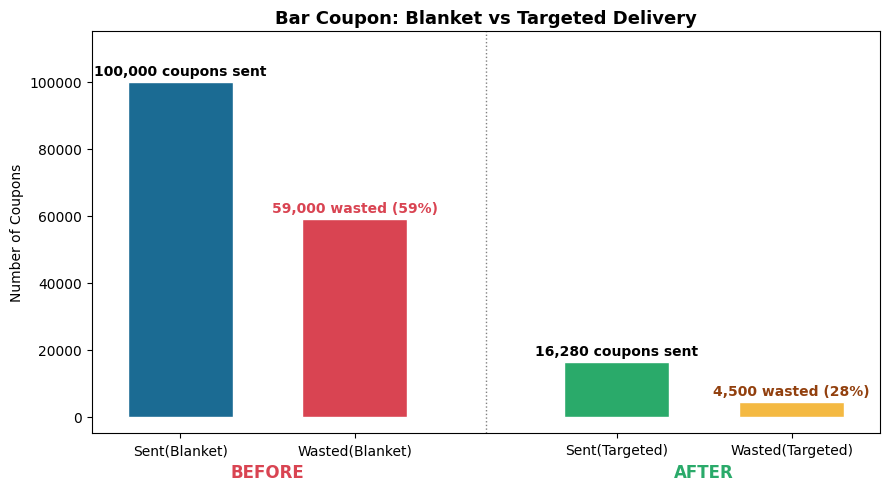

In [53]:
# ── ROI: Blanket vs Targeted Delivery (Bar coupon example) ──────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar([0, 1], [100000, 59000], color=["#1B6B93", "#D94452"], width=0.6, edgecolor="white")
ax.bar([2.5, 3.5], [16280, 4500], color=["#2AAA6A", "#F4B942"], width=0.6, edgecolor="white")

ax.text(0,   102000, "100,000 coupons sent",   ha="center", fontsize=10, fontweight="bold")
ax.text(1,    61000, "59,000 wasted (59%)",    ha="center", fontsize=10, fontweight="bold", color="#D94452")
ax.text(2.5,  18280, "16,280 coupons sent",   ha="center", fontsize=10, fontweight="bold")
ax.text(3.5,   6500, "4,500 wasted (28%)",    ha="center", fontsize=10, fontweight="bold", color="#92400E")

ax.set_xticks([0, 1, 2.5, 3.5])
ax.set_xticklabels(["Sent(Blanket)", "Wasted(Blanket)", "Sent(Targeted)", "Wasted(Targeted)"])

ax.axvline(1.75, color="gray", linestyle=":", linewidth=1)
ax.text(0.5,  -18000, "BEFORE", ha="center", fontsize=12, fontweight="bold", color="#D94452")
ax.text(3.0,  -18000, "AFTER",  ha="center", fontsize=12, fontweight="bold", color="#2AAA6A")

ax.set_ylabel("Number of Coupons")
ax.set_title("Bar Coupon: Blanket vs Targeted Delivery", fontsize=13, fontweight="bold")
ax.set_ylim(-5000, 115000)
plt.tight_layout()
plt.show()
